# Семинар 6. Нелинейные уравнения

*Внимание! Семинар содержит интерактивные демонстрации. На сайте они представлены в статическом виде. Для работы интерактивных элементов необходимо скачать страницу в формате ipynb и запустить ipynb-файл локально.*

Перед изучением материалов семинара рекомендуем посетить лекцию или посмотреть видеозапись лекции. Ссылки (YouTube): [лекция 6](https://m.youtube.com/watch?v=BUTUuvs724M&t=28m49s) (начало темы), [лекция 7](https://m.youtube.com/watch?v=0UtUfkqH7v8&pp=0gcJCRsBo7VqN5tD&t=62s) (продолжение).

Предполагается, что читатель знает

* теорему Больцано—Коши о промежуточном значении,
* определения выпуклости (выпуклости вниз) и вогнутости (выпуклости вверх) функции на отрезке, а также достаточное условие выпуклости в терминах второй производной.

# Введение

Во многих задачах прикладной математики, физики и других наук возникает необходимость решать **нелинейные уравнения**. Это уравнения вида

$$f(x)=0,$$

левая часть которых представляет собой **нелинейную функцию** $f(x)$, т.е. функцию, не являющуюся линейной (помимо нелинейности предполагается также её **непрерывность**, а иногда — и гладкость). Напомним, что функция $g:L\to \mathbb{F}$ называется **линейной**, если она удовлетворяет условиям

$$g(l_1+l_2)=g(l_1)+g(l_2),\quad g(\alpha l)=\alpha g(l)$$

для любых элементов $l$, $l_1$, $l_2$ линейного пространства $L$ и любого элемента $\alpha$ числового поля $\mathbb{F}$. Другие названия линейных функций — **линейные функционалы** и **линейные формы** (или 1-формы).

В вычислительной математике мы, как правило, считаем, что $L\equiv \mathbb{R}$, $\mathbb{F}\equiv \mathbb{R}$. В этом случае класс линейных функций оказывается узким и ограничивается **однородными** полиномами вида $P(x)=ax$. Впрочем, иногда линейными функциями называют и **неоднородные** полиномы $Q(x)=ax+b$ ($b\neq 0$). При этом термин "линейная" в названии функции употребляется в "школьном" смысле: имеется в виду, что графики функций $y=Q(x)$ в плоскости $(x,y)$ представляют собой прямые.

Из сказанного ясно, что даже сравнительно простые уравнения, содержащие элементарные функции и их комбинации, оказываются нелинейными. Этим объясняется широкая распространённость нелинейных уравнений. Хорошо известно, что **общих методов их решения не существует**, и поэтому очень часто такие уравнения приходится решать численно.

При рассмотрении нелинейных уравнений, как правило, обсуждаются две взаимосвязанные задачи. Первая задача — это **задача локализации корня** уравнения, т.е. задача поиска отрезка $[a,b]\subset\mathbb{R}$, содержащего **один и только один** корень $x=\xi$ уравнения $f(x)=0$. Если уравнение имеет несколько корней и ставится задача отыскать все корни, то отрезок локализации должен быть указан для каждого корня.

Достаточное условие существования корня на отрезке $[a,b]$ заключается в том, чтобы знаки **непрерывной** функции $f(x)$ на концах этого отрезка были различны: $f(a)f(b)<0$. Это условие следует из теоремы Больцано—Коши о промежуточном значении. Заметим, что оно **не гарантирует единственности корня** — при выполнении условия $f(a)f(b)<0$ **нельзя даже утверждать, что количество корней**, расположенных на отрезке $[a,b]$, **нечётно** (функция может менять знак на отрезке нечётное число раз, но при этом иметь на том же отрезке нуль чётной кратности — см. рисунок ниже). Единственным корень будет, например, в том случае, если производная $f'(x)$ существует и сохраняет постоянный знак на интервале $(a,b)$.

![image](pic/sem06_func.png)

*К обсуждению недостаточности условия $f(a)f(b)<0$ для единственности корня нелинейного уравнения $f(x)=0$ на отрезке $[a,b]$. Из рисунка также следует, что количество нулей функции $f(x)$ может не совпадать с количеством точек перемены знака. В приведённом примере функция имеет два нуля $\xi_1,\xi_2\in[a,b]$, причём второй нуль совпадает с точкой локального минимума*

Подчеркнём также, что условие $f(a)f(b)<0$ **не является необходимым** условием существования корня на отрезке $[a,b]$. В этом легко убедиться, рассмотрев, например, функцию $f(x)=(x-2)^4$. Она принимает положительные значения на всей числовой оси, за исключением точки $x=2$, являющейся её нулём. Взяв любые $a$ и $b$ так, чтобы выполнялось неравенство $a<2<b$, получим отрезок $[a,b]$ локализации корня. При этом значения $f(a)$ и $f(b)$ положительны, так что условие $f(a)f(b)<0$ не выполнено, хотя корень $x=2$ на отрезке $[a,b]$ существует.

Вторая из упомянутых выше задач заключается в **отыскании локализованного корня с заданной точностью**. Образно говоря, требуется "стянуть" **заранее известный** отрезок локализации $[a,b]$ так, чтобы он по-прежнему содержал корень уравнения $x=\xi$. Чем меньше длина отрезка локализации корня, тем меньше погрешность, с которой известен этот корень.

На практике обе задачи — локализация корня и его уточнение — рассматриваются как два последовательных этапа решения данного нелинейного уравнения. Однако задача локализации относится, по существу, не к вычислительной математике, а к математическому анализу, поскольку для выделения отрезка локализации обычно используются какие-то свойства функции $f(x)$, её график или некоторые специальные **аналитические** приёмы. Численные же методы применяются в основном для решения второй задачи — **итерационного уточнения корня** до достижения наперёд заданной погрешности $\varepsilon$.

Все численные методы решения нелинейных уравнений можно разделить на два класса: **одноточечные** и **многоточечные**. Как ясно из названия, в методах первого класса каждое следующее приближение $x^{(s+1)}$ к искомому корню $x=\xi$ находится по текущему приближению $x^{(s)}$, т.е. для расчёта нового приближения нужна только **одна точка**. Методы же второго класса требуют знания нескольких предыдущих приближений (**нескольких точек**) для поиска нового приближения. Отсюда как будто бы следует, что одноточечные методы заведомо более удобны, раз для их использования достаточно задать лишь начальное приближение $x^{(0)}$: может показаться, что для применения некоторого одноточечного метода нет необходимости проделывать первый этап решения уравнения — определять локализацию корня. Однако этот вывод неверен. Для корректного выбора начального приближения  $x^{(0)}$ искомый корень $x=\xi$ нужно предварительно локализовать (и желательно в достаточно малом отрезке), т.е. требуется, в сущности, отыскать на числовой прямой несколько точек. Если этого не сделать, то метод может сойтись к другому корню или не сойтись вообще.

Что же касается собственно многоточечных методов, то их можно применять лишь после вычисления нескольких первых приближений к корню каким-то другим способом. Из методов этого типа мы будем рассматривать только **двухточечные методы**, которые, как правило, для начала расчёта требуют задания двух известных граничных точек $x=a$ и $x=b$ отрезка локализации корня (эти точки можно рассматривать в качестве первых двух приближений). Отметим, что существуют и методы, использующие большее число точек (например, трёхточечный **метод парабол**).

# Двухточечные методы

## Метод половинного деления

Пусть для нелинейного уравнения $f(x)=0$, в котором $f(x)$ — **непрерывная** функция, задан отрезок $[a,b]$ локализации корня $x=\xi$. Пусть, кроме того, функция $f(x)$ имеет разные знаки на концах отрезка: $f(a)f(b)<0$.

Переобозначим граничные точки отрезка, введя индекс итерации (на протяжении всего раздела будем писать его снизу для компактности обозначений): $a_0\equiv a$, $b_0\equiv b$. На $s$-й итерации метода (нумерацию начинаем с нуля) выполняем следующие действия:

* находим середину отрезка $c_s=(a_s+b_s)/2$,
* проверяем знаки произведений $f(a_s)f(c_s)$ и $f(c_s)f(b_s)$: если первое произведение отрицательно (корень попал в левую половину отрезка), то полагаем $a_{s+1}=a_s$, $b_{s+1}=c_s$; если же отрицательно второе произведение (корень попал в правую половину отрезка), то полагаем $a_{s+1}=c_s$, $b_{s+1}=b_s$,
* итерации повторяем до тех пор, пока длина отрезка локализации на $s$-ой итерации не станет меньше желаемой точности $\varepsilon$:

    $$b_s-a_s\equiv\varepsilon_s<\varepsilon.$$

Иначе говоря, суть метода состоит в том, что отрезок локализации последовательно делится пополам и после каждого деления выбирается та половина, которая содержит корень. Поэтому этот метод и называется **методом половинного деления** (или **методом дихотомии**, или **методом бисекции**).

Ясно, что на втором шаге каждой итерации не обязательно проверять знаки обоих произведений: достаточно проверить знак какого-то одного из них (существование корня на отрезке $[a,b]$ гарантировано — это отрезок локализации — значит, если корня не оказалось в одной половине отрезка, то он попал в другую половину). Может так случиться, что корень $x=\xi$ совпадёт с серединой какого-то отрезка: $\xi=c_s$. В этом случае можно условиться выбирать, например, левую половину отрезка. Таким образом, на каждой итерации нужно проверять выполнение **нестрогого** неравенства $f(a_s)f(c_s)\leq 0$.

После остановки итерационного процесса можно выбрать в качестве приближённого значения корня любую точку последнего отрезка $[a_s,b_s]$ — например, его середину $c_s$; тогда погрешность не превосходит половины длины отрезка, т.е. оказывается не больше величины $\varepsilon_s/2<\varepsilon/2$.

**Метод половинного деления всегда сходится к корню** уравнения $f(x)=0$. Это следует из теоремы Кантора о вложенных отрезках. Напомним её формулировку.

**Теорема 1 (принцип Кантора).** Последовательность вложенных отрезков

$$\big\{[a_n,b_n]: [a_{k+1},a_{k+1}]\subset[a_{k},a_{k}];\phantom{,}n,k\in\mathbb{N}\big\}$$

имеет общую точку. Если эта последовательность является *стягивающейся*, т.е. $b_n-a_n\to 0$ при $n\to\infty$, то общая точка единственна.

В рассматриваемом случае мы имеем дело как раз со стягивающейся последовательностью вложенных отрезков, поскольку каждый следующий отрезок локализации корня лежит во всех предыдущих и имеет меньшую по сравнению с ними длину. То, что общая точка последовательности отрезков совпадает с корнем $x=\xi$, очевидно, поскольку $\xi$ принадлежит всем отрезкам последовательности по построению метода, а общая точка, согласно теореме, единственна.

Так как за каждую итерацию длина отрезка сокращается вдвое, **метод сходится к корню со скоростью геометрической прогрессии**, имеющей знаменатель $q_\text{dich}=1/2$. Это значит, что

$$|\xi-c_{s+1}|\leq \varepsilon_{s+1},\quad |\xi-c_{s}|\leq \varepsilon_{s},\quad\text{причём}\quad \varepsilon_{s+1}= \frac{1}{2}\varepsilon_{s}.$$

В подобных случаях говорят также о **линейной сходимости**, поскольку величина $\varepsilon_{s}$ входит в последнее неравенство в первой степени.

Легко оценить число итераций, необходимое для достижения заданной точности $\varepsilon$. Из неравенства

$$\varepsilon_s=\frac{\varepsilon_0}{2^s}<\varepsilon$$

логарифмированием получаем:

$$s>(\ln 2)^{-1}\cdot\ln\frac{\varepsilon_0}{\varepsilon}=(\ln 2)^{-1}\cdot\ln\frac{b_0-a_0}{\varepsilon}.$$

Отсюда видно, что для уточнения 16 десятичных знаков корня, доступных при расчётах с двойной точностью, достаточно выполнить порядка $\ln 10^{16}/\ln 2\simeq 54$ итераций.

Программная реализация метода половинного деления:

In [113]:
import numpy as np

def dichotomy(f, a: float, b: float, eps: float = 1e-8):
    s = np.log((b - a) / eps) / np.log(2)
    s = int(np.ceil(s)) # округляем до целого вверх

    # переменные f_left и f_c введены специально: чтобы на каждой итерации
    # функция f(x) вызывалась лишь один раз (см. разъяснения ниже)
    f_left = f(a)

    for i in range(s):
        c = (a + b) / 2
        f_c = f(c) # единственный вызов функции f(x) в течение итерации

        if f_left * ( f_c / max(abs(f_left), abs(f_c)) ) <= 0:
            b = c
        else:
            a = c
            f_left = f_c

    return (a + b) / 2, s

Подчеркнём, что в предложенной программе при выборе нового отрезка локализации вместо условия $f(a_s)f(c_s)\leq 0$ проверяется условие

$$f(a_s)\cdot \frac{f(c_s)}{\text{max}\big(|f(a_s)|, |f(c_s)|\big)}\leq 0.$$

Ясно, что с точки зрения "чистой" математики оба условия эквивалентны (при отличном от нуля знаменателе в последнем неравенстве). Но в компьютерной арифметике при очень малых значениях $|f(a_s)|$ и $|f(c_s)|$ произведение $f(a_s)f(c_s)$ может выйти за пределы точности и обратиться в машинный нуль, что, конечно, нарушит работу алгоритма. Поэтому на практике предпочтительнее пользоваться вторым условием: дополнительное деление на $\text{max}\big(|f(a_s)|, |f(c_s)|\big)$ равносильно нормировке одного из сомножителей на единицу и служит страховкой от потери точности. Максимум приходится находить для того, чтобы при случайном совпадении корня с граничной точкой очередного отрезка локализации не возникало деления на нуль (очевидно, что значения $f(a_s)$ и $f(c_s)$ не могут равняться нулю одновременно). Заметим, что **в программе при вычислении левой части неравенства первым действием должно осуществляться именно деление** (иначе видоизменение проверяемого условия утратит смысл).

Найдём с помощью запрограммированной функции **положительный** корень уравнения $f(x)=0$, где $f(x)=\sin x+x^2-1$. Очевидно, что $f(0)=-1<0$, $f(1)=\sin 1>0$, а $f'(x)=\cos x + 2x>0$ при $x\geq 0$, поэтому в качестве отрезка локализации можно выбрать отрезок $[0,1]$. При вызове функции ```dichotomy``` потребуем, чтобы корень был найден с точностью $\varepsilon=10^{-4}$. Выведем на печать приближённое значение корня и количество итераций, за которое оно найдено. Дополнительно измерим время работы программы:

In [114]:
f = lambda x: np.sin(x) + x**2 - 1

%time root, iter = dichotomy(f, 0, 1, 10**(-4))

CPU times: user 111 µs, sys: 9 µs, total: 120 µs
Wall time: 122 µs


In [115]:
(root, iter)

(0.636749267578125, 14)

Можно было бы воспользоваться готовой реализацией метода половинного деления из модуля ```optimize``` библиотеки ```scipy``` ([документация](https://docs.scipy.org/doc/scipy/reference/optimize.html)). Соответствующая функция называется ```bisect``` ([документация](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.bisect.html)) и принимает на вход три обязательных аргумента: левую часть уравнения $f(x)$ и границы отрезка локализации $a$ и $b$. Можно также задать необязательные аргументы: ```xtol```, ```rtol``` и ```maxiter```. Из них первые два предназначены для регулировки точности искомого приближения к корню и имеют тот же смысл, что и в функциях ```np.allclose``` и ```np.isclose``` (см. третий семинар): найденное функцией приближение $x$ будет удовлетворять условию

$$|\xi-x|\leq\text{atol}+\text{rtol}\cdot |x|.$$

Аргумент ```maxiter``` ограничивает количество выполняемых итераций.

Пример вызова функции ```bisect```:

In [116]:
from scipy.optimize import bisect

%time root = bisect(f, 0, 1, xtol=10**(-4))

CPU times: user 178 µs, sys: 15 µs, total: 193 µs
Wall time: 198 µs


In [117]:
root

0.63677978515625

Помимо приближённого значения корня можно получить дополнительную информацию, в том числе количество совершённых итераций. Для этого нужно указать ещё один необязательный аргумент функции: ```full_output = True```.

In [118]:
bisect(f, 0, 1, xtol=10**(-4), full_output=True)

(0.63677978515625,
       converged: True
            flag: converged
  function_calls: 16
      iterations: 14
            root: 0.63677978515625
          method: bisect)

**Упражнение.** Из сравнения результатов работы пользовательской функции ```dichotomy``` и встроенной функции ```bisect``` видно, что в обоих случаях количество итераций метода половинного деления оказалось равным 14. Почему при этом найденные приближения к корню совпадают только в первых четырёх знаках после запятой? Значит ли это, что пользовательская программа написана неправильно?

*Указание.* Попробуйте поменять вывод в функции ```dichotomy``` (замените середину отрезка на одну из его граничных точек). Совпадают ли теперь результаты работы функций ```dichotomy``` и ```bisect```? Что это значит?

**Упражнение.** Из подробного вывода результатов работы функции ```bisect``` видно, что значения функции $f(x)$ вычислялись 16 раз. Почему количество вызовов функции $f(x)$ превосходит количество итераций?

Отметим, что по умолчанию $\text{xtol}= 2\cdot 10^{-12}$, $\text{rtol}\sim 9\cdot 10^{-16}$, поэтому, если заданы только первые три аргумента, функция ```bisect``` находит приближение к корню $x=\xi$ с точностью до 11—12 знаков после запятой (если $|\xi| \lesssim 10^3$). Если же $|\xi|\gtrsim 10^3$, то корень будет найден с относительной точностью, близкой к $\varepsilon_{\text{маш}}$. Заметим также, что относительной точности $\sim  10^{-12}$ обычно достаточно при решении практических задач.

In [119]:
bisect(f, 0, 1, full_output=True)

(0.6367326508061524,
       converged: True
            flag: converged
  function_calls: 41
      iterations: 39
            root: 0.6367326508061524
          method: bisect)

Менять предустановленную точность имеет смысл в тех случаях, когда есть основания считать, что искомый корень очень близок к нулю (или требуется найти корень как можно точнее). Максимально достижимая точность получится, если положить $\text{xtol}$ равным наименьшему субнормальному числу (о субнормальных числах мы упоминали на первом семинаре), т.е. взять $\text{xtol}\simeq 4,9\cdot 10^{-324}$:

In [120]:
bisect(f, 0, 1, xtol=5e-324, full_output=True)

(0.6367326508052824,
       converged: True
            flag: converged
  function_calls: 53
      iterations: 51
            root: 0.6367326508052824
          method: bisect)

Подчеркнём, что перед запуском процесса функция ```bisect``` проверяет выполнение условия $f(a)f(b)<0$, обеспечивающего корректную работу алгоритма. При отрицательном результате проверки возбуждается исключение. Попробуем, например, найти корень уравнения $f(x)=0$, где $f(x)=(x-2)^4\geq 0$ (эту функцию мы уже рассматривали во введении). В качестве отрезка локализации возьмём $[0, 4]$:

In [121]:
f = lambda x: (x - 2)**4

try:
    bisect(f, 0, 4)
except Exception as e:
    print(e)

f(a) and f(b) must have different signs


**Упражнение.** Попытка найти корень последнего уравнения с помощью написанной выше функции ```dichotomy``` приводит к неожиданному результату — получается правильный ответ:

In [122]:
f = lambda x: (x - 2)**4

dichotomy(f, 0, 4, eps=1e-16)

(2.0, 56)

Однако выше утверждалось, что если условие $f(a)f(b)<0$ не выполнено, то метод половинного деления не работает. Как разрешается это противоречие?

*Указание.* Попробуйте поменять отрезок локализации в последнем вызове функции ```dichotomy```. Объясните результат.

Достоинствами метода половинного деления являются его **исключительная простота** и связанная с ней **надёжность** (как уже говорилось, сходимость к корню обеспечивается всегда). Кроме того, метод предъявляет **скромные требования к функции** $f(x)$: по сути, нужна только её непрерывность; дифференцируемость или гладкость не требуются.

К недостаткам метода часто относят медленную сходимость и потребность предварительно находить отрезок локализации корня. Однако эти недостатки весьма условны. Как мы видели, для достижения точности, близкой к машинной, достаточно выполнить около пятидесяти итераций метода половинного деления. При современном уровне развития вычислительной техники это не так много, тем более что **на каждой итерации функция** $f(x)$ **вызывается только один раз** — для подсчёта значения $f(c_s)$ — в отличие от других методов (как правило, именно вызов функции $f(x)$ оказывается наиболее затратной процедурой). Что же касается отрезка локализации, то его, как станет ясно из дальнейшего, приходится находить всегда, даже если для уточнения корня используется некоторый одноточечный метод (мы уже отмечали это обстоятельство во введении).

Более существенные недостатки метода половинного деления следующие:

* метод не обобщается на случай функций нескольких переменных,
* метод не позволяет находить комплексные корни (например, в случае алгебраических уравнений),
* невозможно найти корни чётной кратности (это верно для любого двухточечного метода),
* для корней нечётной кратности невозможно установить их кратность (а чувствительность процесса к ошибкам округления повышается с увеличением кратности корня).

Несмотря на перечисленные недостатки и кажущуюся примитивность, метод половинного деления до сих пор используется на практике, главным образом, благодаря своей надёжности.

## Метод хорд

В методе половинного деления отрезок локализации на каждой итерации делится пополам **вне зависимости от поведения функции** $f(x)$ на рассматриваемом отрезке. Из-за этого для достижения заданной точности $\varepsilon$ приходится выполнять фиксированное число итераций: оно зависит только от длины исходного отрезка локализации $[a,b]$ и оказывается одинаковым для различных функций $f(x)$.

Чтобы ускорить сходимость, можно предложить более сложную процедуру вычисления приближений $c_s$, которая учитывала бы вид функции $f(x)$. Один из возможных вариантов заключается в следующем. На $s$-й итерации по двум значениям $f(a_s)$ и $f(b_s)$ строится **линейный интерполянт** функции $f(x)$ на отрезке $[a_s,b_s]$:

$$y_s(x)=f(a_s)+\frac{f(b_s)-f(a_s)}{b_s-a_s}(x-a_s).$$

В силу линейности нуль интерполянта находится элементарно:

$$y_s(x)=0\quad \Leftrightarrow\quad x=\zeta\equiv\frac{a_sf(b_s)-b_sf(a_s)}{f(b_s)-f(a_s)}.$$

Точка $\zeta$ и принимается за новое приближение $c_s$ к искомому корню $x=\xi$. Новый отрезок локализации выбирается так же, как в методе половинного деления: если $f(a_s)f(c_s)\leq 0$, то полагаем $[a_{s+1},b_{s+1}]=[a_{s},c_{s}]$, в противном случае $[a_{s+1},b_{s+1}]=[c_{s},b_{s}]$.

**Упражнение.** Докажите, что построенные указанным способом отрезки $[a_s,b_s]$ образуют последовательность вложенных отрезков.

*Указание.* Перепишите формулу для $c_s=\zeta$ в виде $c_s=a_s+\dots$ .

Описанной процедуре поиска приближений к корню можно дать очень наглядную геометрическую интерпретацию (см. анимацию ниже). На очередной итерации метода точки $\big(a_s, f(a_s)\big)$ и $\big(b_s, f(b_s)\big)$ на графике функции соединяются отрезком (**хордой** — отсюда и название метода). Точка пересечения хорды с осью $x$ принимается за точку $c_s$. Из двух получившихся частей отрезка локализации выбирается та часть, на которой происходит смена знака функции $f(x)$; на этом итерация завершается. Далее процесс повторяется уже с новым отрезком локализации.

![image](pic/sem06_bisecant.gif)

*Поиск приближений к корню $x=\xi$ нелинейного уравнения $f(x)=0$ методом хорд. Красным цветом подсвечиваются отрезки локализации*

Отметим, что в некоторых источниках описанный метод называют методом секущих (или методом секущих **с проверкой знаков** — имеется в виду, что на каждой итерации, как и в методе половинного деления, проверяется условие $f(a_s)f(c_s)\leq 0$). Более употребительным является, однако, название "метод хорд" (название "метод секущих" чаще применяют в отношении другого метода — см. ниже).

Обычно при рассмотрении метода хорд предполагают, что на интервале $(a_0,b_0)$ функция $f(x)$ дважды дифференцируема. Это предположение не является существенным для самого метода. Дело просто в том, что если вторая производная $f''(x)$ существует, то по её знаку удобно определять, является ли функция $f(x)$ выпуклой или вогнутой на очередном отрезке локализации $[a_s,b_s]\subset [a_0,b_0]$.

Можно показать, что если внутри отрезка $[a_s,b_s]$ вторая производная $f''(x)$ сохраняет знак, то метод хорд сходится, причём у всех отрезков $[a_{s'},b_{s'}]$ с $s'\geq s$ одна из граничных точек оказывается общей. Эта общая граничная точка "стоит на месте" при итерациях — как точка $b_0$ в приведённой выше анимации. Более конкретно: "стоящей на месте" оказывается та из граничных точек отрезка $[a_s,b_s]$, в которой функция $f(x)$ принимает значение того же знака, что и знак второй производной $f''(x)$ на интервале $(a_s,b_s)$. Кроме того, точки $c_s$ приближаются к корню $x=\xi$ со стороны, противоположной "стоящей на месте" граничной точке, причём приближения образуют **монотонную** последовательность. Все эти закономерности легко понять, взглянув на рисунок (см. ниже). Принимая их во внимание, говорят, что **в методе хорд имеет место монотонная односторонняя сходимость приближений к корню** (при сохранении знака второй производной).

![image](pic/sem06_bisecant_cases.png)

*Сходимость приближений, полученных методом хорд, к корню нелинейного уравнения $f(x)=0$ при разных знаках второй производной $f''(x)$. Красным цветом выделены приближения к корню, синим — "стоящая на месте" граничная точка*

**Упражнение.** Изобразите график функции $f(x)$, для которой приближения $c_s$, полученные на **каких-нибудь** двух последовательных итерациях метода хорд, оказываются по разные стороны от корня $x=\xi$ нелинейного уравнения $f(x)=0$.  

Следует помнить, что существование на интервале $(a_0,b_0)$ второй производной $f''(x)$, сохраняющей знак на подынтервале $(a_s,b_s)\subset(a_0,b_0)$, — это лишь **достаточное** условие сходимости метода хорд. **Необходимого** же условия сходимости **в общем случае** не сформулировано — многое зависит от вида функции $f(x)$. Впрочем, встречающиеся на практике функции обычно имеют (непрерывную) вторую производную в малой окрестности своего нуля $x=\xi$ или являются выпуклыми (либо вогнутыми) в этой окрестности. Но тогда процедура поиска корня методом хорд, начиная с некоторой итерации, сводится к одной из четырёх изображённых выше ситуаций. В известной авторам литературе нет контрпримеров, в которых метод хорд не сходится (и попытки авторов построить подобную функцию не увенчались успехом), но нет и доказательства сходимости метода, справедливого при достаточно общих предположениях о функции $f(x)$. Отметим, однако, что **метод хорд менее надёжен, чем метод половинного деления: в ряде случаев он сходится очень медленно**. Проблемы со сходимостью возникают, например, тогда, когда нуль $x=\xi$ совпадает с точкой перегиба функции $f(x)$ (как у функции $f(x)=x^3$) или функция имеет другие особенности на исходном отрезке локализации. Несколько подобных примеров мы приведём ниже.

Отношение длин отрезков локализации $q=\varepsilon_{s+1}/\varepsilon_{s}$ в методе хорд, вообще говоря, меняется от итерации к итерации и может быть как меньше, так и больше $q_\text{dich}=1/2$. Поэтому **в общем случае** затруднительно дать аналитический анализ сходимости метода и сравнить его с методом половинного деления. С другой стороны, легко усмотреть, что заметная экономия в итерациях получается тогда, когда в окрестности корня функция $f(x)$ **близка к линейной**. Это вытекает из простого наблюдения: для функции $f(x)=ax+b$ метод хорд даёт точный ответ (с поправкой на ошибки округления) за одну итерацию.

Приступая к программной реализации метода хорд, необходимо иметь в виду, что вопрос о критерии остановки его итераций не так прост, как может показаться на первый взгляд. Из приведённого выше рисунка очевидно, что **выбирать в качестве этого критерия малость отрезка локализации** (как в методе половинного деления) **нельзя**: поскольку сходимость приближений $c_s$ к корню $x=\xi$ односторонняя, длина отрезка локализации не может стать меньше расстояния от точки $\xi$ до граничной точки, "стоящей на месте". Если требуемая точность корня $\varepsilon$ меньше этого расстояния, то при указанном критерии итерационный процесс никогда не будет остановлен.

Во многих книгах рекомендуется использовать в качестве условия прекращения итераций неравенство $|c_{s+1}-c_s|<\varepsilon$, т.е. проверять **близость двух последовательных приближений к корню**. Однако этот критерий применим лишь с существенными оговорками, и ошибочно полагать, что им можно пользоваться всегда. Если речь идёт именно о методе хорд, то критерий $|c_{s+1}-c_s|<\varepsilon$ приемлем в случаях, когда на интервале $(a,b)$ сохраняет знак не только вторая производная $f''(x)$, но и первая производная $f'(x)$; кроме того, исходный отрезок локализации должен быть выбран настолько узким, что

$$\max_{x\in[a_0,b_0]}f'(x)\leq 2\cdot\min_{x\in[a_0,b_0]}f'(x).$$

При сделанных допущениях гарантируется, что если

$$|c_{s+1}-c_s|\leq\varepsilon,\quad\text{то и}\quad |\xi-c_{s+1}|\leq\varepsilon.$$

Если же перечисленные условия не выполнены, то возможна ситуация, наглядно представленная на нижеследующем рисунке: функция полога на большей части отрезка локализации и резко возрастает в окрестности своего нуля. Тогда из геометрических соображений очевидно, что при малом расстоянии $|c_{s+1}-c_s|$ приближение $c_{s+1}$ может оказаться далёким от корня.

![image](pic/sem06_crit.png)

*К обсуждению недостаточности условия $|c_{s+1}-c_s|<\varepsilon$ для близости приближения, полученного методом хорд, к корню $x=\xi$ нелинейного уравнения $f(x)=0$. Расстояние между точками $c_8$ и $c_7$ (т.е. итерационная поправка) явно меньше расстояния между точками $\xi$ и $c_8$ (т.е. погрешности корня)*

Ясно, что на практике далеко не всегда есть возможность предварительно проверить корректность критерия $|c_{s+1}-c_s|<\varepsilon$ остановки итераций метода хорд. Поэтому обычно это условие либо вообще не используется, либо дополняется некоторым другим условием (см. ниже).

Подчеркнём, что недостаточность условия $|c_{s+1}-c_s|<\varepsilon$ для малости погрешности $|\xi-c_{s+1}|$ надо иметь в виду при организации **любых методов с односторонней сходимостью** приближений к корню. Отметим, что для методов, в которых приближения оказываются попеременно то с одной, то с другой стороны от корня (т.е. для методов с **двусторонней сходимостью**), критерий $|c_{s+1}-c_s|<\varepsilon$ остановки итераций вполне применим. Например, им можно пользоваться в методе половинного деления (если рассматривать границы очередного отрезка $[a_s,b_s]$ в качестве двух последовательных приближений к корню), хотя это и не имеет практического смысла, поскольку в методе половинного деления возможна априорная оценка числа итераций.

Не следует, вообще говоря, полагаться и на другой критерий остановки итераций, который некоторые авторы тоже ошибочно считают достаточным для обеспечения малой погрешности корня (и в методе хорд, и в других методах). Речь идёт об условии $|f(c_s)|<\varepsilon$. Действительно, поскольку $f(\xi)=0$, представляется естественным, что если величина $f(c_s)$ мало отличается от нуля, то и приближение $c_s$ мало отличается от корня $x=\xi$. Однако в общем случае это не так.

Несостоятельность критерия $|f(c_s)|<\varepsilon$ видна хотя бы из того, что домножение уравнения $f(x)=0$ на произвольное ненулевое число $\alpha$ приводит к эквивалентному уравнению $\widetilde f(x)=\alpha f(x)=0$ (с тем же корнем $x=\xi$). При этом **приближения** $c_s$, полученные, скажем, в методе хорд, **не меняются**, но меняется величина $|f(c_s)|$: $|\widetilde f(c_s)|=|\alpha|\cdot|f(c_s)|$. Подбором соответствующего $\alpha$ всегда можно добиться выполнения условия $|\widetilde f(c_s)|<\varepsilon$ для одного и того же $c_s$. Отсюда ясно, что **требование** $|f(c_s)|<\varepsilon$ **произвольно и ещё не гарантирует близости приближения** $c_s$ **к корню** $x=\xi$. Это верно для **любого** метода (как двухточечного, так и одноточечного; как с односторонней сходимостью, так и с двусторонней сходимостью), а не только для метода хорд. В справедливости сделанного замечания (в общем случае) убеждает также следующий рисунок.

![image](pic/sem06_crit2.png)

*К обсуждению несостоятельности критерия $|f(c_s)|<\varepsilon$ остановки некоторого итерационного процесса, использующегося для решения нелинейного уравнения $f(x)=0$ с корнем $x=\xi$. В случае, изображённом слева, этот критерий выполнен, а приближение $c_s$ расположено далеко от $\xi$. Справа приведён пример противоположного случая: приближение $c_s$ близко к корню, а величина $|f(c_s)|$ велика*

На практике корректный критерий остановки итераций метода хорд рекомендуется формулировать в виде **системы из двух** упомянутых выше **условий**:

$$\begin{cases}
    |c_{s+1}-c_s|<\varepsilon_c, \\[0.2cm]
    |f(c_{s+1})|<\varepsilon_f,
  \end{cases}$$

причём величины $\varepsilon_c$ и $\varepsilon_f$ можно выбирать как равными, так и неравными. Недостаток такого критерия заключается в том, что первое условие (малость итерационной поправки) нельзя проверить на первой же итерации, поскольку для его проверки необходимо знать два последовательных приближения к корню. Обойти это затруднение можно по-разному. Например, можно для любой функции $f(x)$ проводить не менее двух итераций метода хорд или просто отказаться от первого условия на первой итерации (правда, последний вариант рискован: мы видели, что одно только неравенство $|f(c_s)|<\varepsilon_f$ не может служить корректным критерием остановки процесса).

Надо сказать, что рассмотренные выше трудности возникают при формулировке условия прекращения итераций для любого метода решения нелинейных уравнений с **односторонней** сходимостью приближений к корню.

Итак, программная реализация метода хорд может иметь следующий вид (как и на четвёртом семинаре, избегаем цикла ```while```):

In [123]:
def bisecant(f, a: float, b: float,
             eps_c: float = 1e-8, eps_f: float = 1e-8, maxiter: int = 60):
    # переменные f_left, f_right и f_c введены специально: чтобы на каждой итерации
    # функция f(x) вызывалась лишь один раз
    f_left = f(a)
    f_right = f(b)

    # для второго варианта критерия остановки процесса
    #c_prev = (a * f_right - b * f_left) / (f_right - f_left)

    for i in range(maxiter):
        c = (a * f_right - b * f_left) / (f_right - f_left)
        f_c = f(c) # единственный вызов функции f(x) в течение итерации

        if f_left * ( f_c / max(abs(f_left), abs(f_c)) ) <= 0:
            b = c
            f_right = f_c
        else:
            a = c
            f_left = f_c

        if i != 0 and abs(c - c_prev) < eps_c and abs(f_c) < eps_f:
        #if abs(c - c_prev) < eps_c and abs(f_c) < eps_f:
            break

        c_prev = c

    return c, i + 1

Функция ```bisecant``` выполняет не менее двух итераций метода хорд (чтобы сделать возможной проверку малости итерационной поправки). Можно использовать комментированный вариант критерия прекращения цикла, но тогда перед запуском процесса следует присвоить какое-то значение переменной ```c_prev```, иначе проверка условия ```abs(c - c_prev) < eps_c``` в конце первой итерации вызовет ошибку. В предложенной программе перед началом цикла переменной ```c_prev``` присваивается то же значение, что и переменной ```c``` на первой итерации (см. комментированную строку). Таким образом, условие ```abs(c - c_prev) < eps_c``` на первой итерации заведомо выполнено и проверяется, по сути, только условие ```abs(f_c) < eps_f``` (что не вполне надёжно, как мы уже отмечали). На последующих же итерациях "работают" оба условия.

Пример использования написанной программы (в первом варианте, когда выполняется не менее двух итераций) для уравнения $f(x)=0$ с функцией $f(x)=\sin x+x^2-1$ из предыдущего подраздела:

In [124]:
f = lambda x: np.sin(x) + x**2 - 1

%time root, iter = bisecant(f, 0, 1, eps_c=1e-4, eps_f=1e-4)

CPU times: user 122 µs, sys: 10 µs, total: 132 µs
Wall time: 136 µs


In [125]:
(float(root), iter)

(0.6367215022781226, 5)

Как видим, нахождение корня с точностью $\varepsilon=10^{-4}$ потребовало пяти итераций метода хорд. Для метода половинного деления при той же точности понадобилось 14 итераций (см. предыдущий подраздел). Таким образом, **в данном случае** метод хорд оказался более эффективным.

На том же примере легко убедиться в том, что изменение **каждой** из величин $\varepsilon_c$ и $\varepsilon_f$ влияет на количество выполняемых итераций, т.е. в критерии остановки процесса действительно **существенны оба условия** — и на малость итерационной поправки $|c_{s+1}-c_s|$, и на малость величины $|f(c_s)|$:

In [126]:
from ipywidgets import interact, FloatLogSlider

eps_c_w = FloatLogSlider(min=-20, max=0, step=1, base=10, value=1e-4)
eps_f_w = FloatLogSlider(min=-20, max=0, step=1, base=10, value=1e-4)

def bisecant_eps(eps_c: float, eps_f: float):
    f = lambda x: np.sin(x) + x**2 - 1
    root, iter = bisecant(f, 0, 1, eps_c=eps_c, eps_f=eps_f)

    return (float(root), iter)

interact(bisecant_eps, eps_c=eps_c_w, eps_f=eps_f_w);

interactive(children=(FloatLogSlider(value=0.0001, description='eps_c', max=0.0, min=-20.0, step=1.0), FloatLo…

Можно также проверить, что методом хорд корень уравнения вида $ax + b=0$ находится за одну итерацию (правда, для этого следует воспользоваться вторым вариантом функции ```bisecant``` — необходимо отказаться от безусловного выполнения двух итераций метода):

In [127]:
f = lambda x: 2*x - 1

# перед выполнением этого вызова следует поменять критерий остановки процесса
# в функции bisecant и раскоммментировать присвоение c_prev = ... перед циклом
bisecant(f, 0, 1)

(0.5, 2)

Приведём два примера, в которых метод хорд сходится плохо.

Для первого примера возьмём уравнение $e^{x-1}=1$ с корнем $\xi=1$, т.е. положим $f(x)=e^{x-1}-1$. Поскольку $f(0)<0$ и $f(x>1)>0$, в качестве левой границы отрезка локализации можно выбрать точку $a=0$, а в качестве правой — любое $b>1$. Будем решать уравнение с помощью функции ```bisecant``` при различных $b$:

In [128]:
from ipywidgets import IntSlider, FloatSlider

b_int_w = IntSlider(min=0, max=100, step=1, value=1) # "грубая" настройка b - по целым значениям
b_dec_w = FloatSlider(min=0.01, max=0.99, step=0.01, value=0.5) # "точная" настройка b - по сотым долям

def bisecant_exp(b_int: int, b_dec: float):
    f = lambda x: np.exp(x - 1) - 1
    root, iter = bisecant(f, 0, b_int + b_dec,
                          eps_c=1e-2, eps_f=1e-2, maxiter=10000)

    print('Отрезок локализации: [0, {:}]'.format(b_int + b_dec))
    print('Найденный корень и число итераций: ', (float(root), iter))

    return

interact(bisecant_exp, b_int=b_int_w, b_dec=b_dec_w);

interactive(children=(IntSlider(value=1, description='b_int'), FloatSlider(value=0.5, description='b_dec', max…

Видно, что пока отрезок локализации сравнительно узок, корень находится правильно за приемлемое число итераций. Однако если отодвинуть правую границу отрезка далеко, положив $b=100$, то метод хорд не сойдётся к корню даже за $10^4$ итераций (хотя погрешности $\varepsilon_c$ и $\varepsilon_f$ выбраны очень крупными: по $10^{-2}$ каждая!).

С другой стороны, метод половинного деления легко справляется с задачей при $b=100$, даже если требуемая точность равна $10^{-16}$. Количество итераций при этом оказывается равным 60 (что вполне согласуется с оценкой, приведённой в предыдущем разделе):

In [129]:
f = lambda x: np.exp(x - 1) - 1

dichotomy(f, 0, 100, eps=1e-16)

(1.0, 60)

**Упражнение.** Чем объясняется плохая сходимость метода хорд в приведённом примере?

*Подсказка.* Как ведёт себя функция $g(x)=e^x$ при $x\to\infty$?

Предыдущий пример может показаться искусственным, поскольку в нём правая граница отрезка локализации намеренно очень удалена от корня. Для убедительности приведём другой пример. Возьмём $f(x)=(x-1)^3$. Достаточно взять отрезок локализации $[0,3]$ и положить $\varepsilon_c=\varepsilon_f=10^{-6}$ (на практике эту точность едва ли можно считать удовлетворительной), чтобы у метода хорд возникли значительные трудности:

In [130]:
f = lambda x: (x - 1)**3

root, iter = bisecant(f, 0, 3, eps_c=1e-6, eps_f=1e-6, maxiter=10000)
(float(root), iter)

(0.9859593678514783, 10000)

Метод хорд достиг максимально допущенного при вызове функции ```bisecant``` числа итераций (явно чрезмерного для такой простой задачи!) и всё-таки не нашёл корень с требуемой точностью $10^{-6}$. При этом у метода половинного деления не возникает никаких проблем даже при точности $10^{-16}$:

In [131]:
f = lambda x: (x - 1)**3

dichotomy(f, 0, 3, eps=1e-16)

(1.0, 55)

Если же взять точность $10^{-6}$ (т.е. поставить методы в равные условия не только в смысле отрезка локализации, но и в смысле требуемой погрешности корня), то число итераций в методе половинного деления и вовсе окажется в два с половиной раза меньше:

In [132]:
f = lambda x: (x - 1)**3

dichotomy(f, 0, 3, eps=1e-6)

(1.0000001192092896, 22)

**Упражнение.** Почему в приведённом примере метод хорд сходится так плохо? Объясните также следующий факт. Если изменить отрезок локализации с $[0,3]$ на $[0,2]$, то метод хорд решит уравнение $(x-1)^3=0$ всего за одну итерацию даже при точности $10^{-16}$ (у нас итераций получается две, поскольку функция ```bisecant``` в первом варианте выполняет минимум две итерации метода хорд):

In [133]:
f = lambda x: (x - 1)**3

root, iter = bisecant(f, 0, 2, eps_c=1e-16, eps_f=1e-16, maxiter=10000)
(float(root), iter)

(1.0, 2)

Если же взять отрезок локализации ещё более узким, то результат снова получается неудовлетворительным:

In [134]:
f = lambda x: (x - 1)**3

root, iter = bisecant(f, 0, 1.9, eps_c=1e-16, eps_f=1e-16, maxiter=10000)
(float(root), iter)

(1.0070068648033506, 10000)

*Подсказка.* Обратите внимание на свойства функции $f(x)=(x-1)^3$. Что происходит в окрестности точки $x=1$?

Заметим, что метод хорд, как и метод половинного деления, требует подбирать исходный отрезок локализации $[a,b]$ так, чтобы $f(a)f(b)<0$. В противном случае метод выдаёт некорректный результат:

In [135]:
f = lambda x: (x - 2)**4

root, iter = bisecant(f, 1, 4)
(float(root), iter)

(2.4007212799132147, 60)

**Упражнение.** В последнем упражнении предыдущего подраздела мы привели пример с той же функцией $f(x)=(x-2)^4$, в котором метод половинного деления неожиданно нашёл верный ответ, хотя условие $f(a)f(b)<0$ не было выполнено. Может ли такое случиться с методом хорд? Попробуйте поменять в предыдущей ячейке отрезок локализации на $[0,4]$. Объясните результат.

**Метод хорд обладает всеми** перечисленными выше **недостатками метода половинного деления** и, кроме того, ему присущи, как мы видели, два других недостатка:

* необходимого условия сходимости метода хорд **в общем случае** не сформулировано (и поэтому возникают сомнения в его надёжности),
* сходимость приближений к корню оказывается **односторонней** (что затрудняет формулировку условия прекращений итераций).

С другой стороны, в случае "хороших" функций $f(x)$ (без особенностей на исходном отрезке локализации) метод хорд, как правило, требует меньшего числа итераций, чем метод половинного деления.

Встроенных программных реализаций метода хорд в библиотеках Python нет.

## Метод Брента

Существенный недостаток метода хорд заключается, как мы видели, в том, что сходимость приближений к корню решаемого уравнения часто оказывается односторонней. Из-за этого возникают трудности при формулировке критерия остановки итераций, а в некоторых специальных случаях метод сходится очень плохо.

Для устранения этих недостатков можно предложить гибридный метод, сочетающий черты методов половинного деления и хорд. Суть этого метода состоит в том, что по двум известным граничным точкам отрезка локализации корня получают две граничные точки нового отрезка локализации (как в методе половинного деления), причём **по возможности** новые точки строят путём линейной интерполяции функции $f(x)$ (как в методе хорд) с целью ускорения сходимости.

Алгоритм выглядит следующим образом:

*  **Первый шаг** выполняется точно так же, как в методе хорд: по известным граничным точкам отрезка $[a_s,b_s]$ строим точку $c_s$ пересечения хорды с осью абсцисс:

   $$c_s=\frac{a_sf(b_s)-b_sf(a_s)}{f(b_s)-f(a_s)}.$$

   Эта точка впоследствии станет одной из граничных точек нового отрезка локализации.

*  На **втором шаге** назначаем **первую вспомогательную точку** $\alpha_s$, выбирая её из точек $a_s$ и $b_s$ так, чтобы произведение $f(\alpha_s)f(c_s)$ было **положительным**. Другую граничную точку отрезка $[a_s,b_s]$ (не выбранную в качестве первой вспомогательной) обозначаем для удобства через $\gamma_s$. По точкам $c_s$ и $\alpha_s$ снова строим линейный интерполянт; точку его пересечения с осью абсцисс выбираем в качестве **второй вспомогательной точки** $\beta_s$:

   $$\beta_s=\frac{c_sf(\alpha_s)-\alpha_sf(c_s)}{f(\alpha_s)-f(c_s)}.$$

   Иначе говоря, на втором шаге из двух частей $[a_s,c_s]$ и $[c_s,b_s]$ отрезка локализации $[a_s,b_s]$ выбирается та часть, в которую корень **не попал**, и по соответствующим этой части граничным точкам строится ещё одна хорда; её пересечение с осью абсцисс и даёт точку $\beta_s$.

*  На **третьем шаге** выполняем проверки, обеспечивающие сходимость к корню не хуже линейной. В ходе этих проверок назначается вторая точка $d_s$ нового отрезка локализации (первая точка уже найдена на первом шаге — это точка $c_s$). Проверяемые условия зависят от результатов второго шага. Именно,

   * если после выполнения второго шага оказалось, что $\alpha_s=a_s$, то выполняем следующие проверки:

      * если $\beta_s > (c_s+\gamma_s)/2$, то полагаем $d_s=(c_s+\gamma_s)/2$; в противном случае полагаем $d_s=\beta_s$,

      * если $d_s < c_s+\varepsilon$, где $\varepsilon$ — наперёд заданная точность искомого приближения к корню, то полагаем $d_s=c_s+\varepsilon$ (в противном случае ничего не меняем);

   * если же после выполнения второго шага оказалось, что $\alpha_s=b_s$, то в проверяемых условиях меняются некоторые знаки:

      * если $\beta_s < (c_s+\gamma_s)/2$, то полагаем $d_s=(c_s+\gamma_s)/2$; в противном случае полагаем $d_s=\beta_s$,

      * если $d_s > c_s-\varepsilon$, то полагаем $d_s=c_s-\varepsilon$ (в противном случае ничего не меняем).

* После завершения третьего шага остаётся назначить точки $c_s$ и $d_s$ граничными точками нового отрезка локализации, учитывая, что если $\alpha_s=a_s$, то $d_s>c_s$ и надо положить $a_{s+1}=c_s$, $b_{s+1}=d_s$, а если $\alpha_s=b_s$, то наоборот $d_s<c_s$ и, соответственно, $a_{s+1}=d_s$, $b_{s+1}=c_s$.

Система проверок, отнесённая к третьему шагу, кажется запутанной, но при внимательном рассмотрении легко понять её цель. После построения второй хорды точка $\beta_s$ в идеале оказывается внутри отрезка с граничными точками $c_s$ и $\gamma_s$. Если этого не случилось (т.е. вторая хорда отбросила нас за пределы отрезка $[a_s,b_s]$), то результат построения второй хорды следует считать неудачным и лучше воспользоваться методом половинного деления. Очевидно, что так же следует поступить и в случае, когда точка $\beta_s$ "подошла" к точке $\gamma_s$ ближе чем на половину длины отрезка с граничными точками $c_s$ и $\gamma_s$. Вторая проверка (при которой используется величина $\varepsilon$) необходима для того, чтобы исключить бессмысленный выбор точки $d_s$ левее точки $c_s+\varepsilon$ (при $\alpha_s=a_s$) или правее точки $c_s-\varepsilon$ (при $\alpha_s=b_s$); правда, для корректности этой проверки принципиально важно выполнение условия $f(c_s)f(c_s\pm\varepsilon)\leq 0$ (а оно, вообще говоря, может и не выполняться).

Описанный метод в некоторых источниках называют **адаптированным** (или модифицированным) **методом Брента**. Подчеркнём, что это название не является общеупотребительным, поэтому, вообще говоря, им лучше не пользоваться. Термин "адаптированный" указывает на отличие изложенного метода от "настоящего" метода Брента, в котором, помимо половинного деления и построения хорд, используется **обратная квадратичная интерполяция** (незначительно ускоряющая сходимость). Способ решения нелинейных уравнений с помощью такой интерполяции мы разберём на одном из следующих семинаров.

Программная реализация "адаптированного метода Брента":

In [136]:
def Brent_adapt(f, a: float, b: float, eps: float = 1e-8, maxiter: int = 60):
    # переменные f_left, f_right и f_c введены специально: чтобы на каждой итерации
    # функция f(x) вызывалась лишь дважды
    f_left = f(a)
    f_right = f(b)

    for i in range(maxiter):
        c = (a * f_right - b * f_left) / (f_right - f_left)
        f_c = f(c) # первый вызов функции f(x) в течение итерации

        if f_left * ( f_c / max(abs(f_left), abs(f_c)) ) > 0:
            beta = (c * f_left - a * f_c) / (f_left - f_c)

            if beta > (c + b) / 2: d = (c + b) / 2
            else: d = beta

            if d <= c + eps: d = c + eps

            a, b = c, d
            f_left, f_right = f_c, f(d) # второй вызов функции f(x) в течение итерации

        else:
            beta = (c * f_right - b * f_c) / (f_right - f_c)

            if beta < (c + a) / 2: d = (c + a) / 2
            else: d = beta

            if d >= c - eps: d = c - eps

            a, b = d, c
            f_left, f_right = f(d), f_c # второй вызов функции f(x) в течение итерации

        if abs(a - b) < eps: break

    return (a + b) / 2, i + 1

Отметим, что в предложенной программе для экономии памяти мы намеренно отказались от использования обозначений $\alpha_s$ и $\gamma_s$, которые были удобны при описании алгоритма. Код содержит расчётные формулы метода, выписанные в явном виде: вместо $\alpha_s$ и $\gamma_s$ подставлены их значения, зависящие от результата проверки условия $f(a_s)f(c_s)>0$. Поскольку **сходимость приближений к корню является двусторонней** (границы очередного отрезка локализации $[a_s,b_s]$ можно рассматривать в качестве двух последовательных приближений), **критерий остановки итераций формулируется просто**: достаточно потребовать, чтобы модуль разности двух "соседних" приближений не превосходил наперёд заданной точности $\varepsilon$.

В уже знакомом нам примере с функцией $f(x)=\sin{x}+x^2-1$ метод демонстрирует неплохой результат: корень находится за три итерации (при прочих равных условиях методу хорд понадобилось пять итераций, а методу половинного деления — 14).

In [137]:
f = lambda x: np.sin(x) + x**2 - 1

%time root, iter = Brent_adapt(f, 0, 1, eps=1e-4)

CPU times: user 113 µs, sys: 9 µs, total: 122 µs
Wall time: 126 µs


In [138]:
(float(root), iter)

(0.6367826381332036, 3)

Однако в некоторых специальных случаях "адаптированный метод Брента" может давать сбои. Например, корень уравнения вида $ax+b=0$ находится за одну итерацию, как и в методе хорд, однако при повышении требований к точности приближения возникает ошибка:

In [139]:
f = lambda x: 2*x - 1

Brent_adapt(f, 0, 1, eps=1e-8) # этот вызов работает

(0.49999999500000003, 1)

In [140]:
try:
    Brent_adapt(f, 0, 1, eps=1e-16) # а этот выдаёт ошибку
except Exception as e:
    print(e)

float division by zero


**Упражнение.** Объясните, почему во втором случае "адаптированный метод Брента" не работает.

Обратимся к примеру с функцией $f(x)=e^{x-1}-1$. Грубое приближение к корню "адаптированный метод Брента" находит даже при очень широком отрезке локализации, и на первый взгляд это существенно отличает его от метода хорд (последний демонстрировал очень медленную сходимость в рассматриваемом примере):

In [141]:
f = lambda x: np.exp(x - 1) - 1

root, iter = Brent_adapt(f, 0, 100, eps=1e-2)
(float(root), iter)

/tmp/ipython-input-1042031323.py:12: RuntimeWarning: divide by zero encountered in scalar divide
  beta = (c * f_left - a * f_c) / (f_left - f_c)


(1.004919090033349, 4)

Однако предупреждение, возникающее при запуске программы, указывает на скрытые проблемы. Их легко обнаружить, повысив требования к точности в предыдущем вызове:

In [142]:
root, iter = Brent_adapt(f, 0, 100, eps=1e-16)
(float(root), iter)

/tmp/ipython-input-1042031323.py:12: RuntimeWarning: divide by zero encountered in scalar divide
  beta = (c * f_left - a * f_c) / (f_left - f_c)
/tmp/ipython-input-1042031323.py:8: RuntimeWarning: divide by zero encountered in scalar divide
  c = (a * f_right - b * f_left) / (f_right - f_left)
/tmp/ipython-input-1042031323.py:11: RuntimeWarning: invalid value encountered in scalar divide
  if f_left * ( f_c / max(abs(f_left), abs(f_c)) ) > 0:
/tmp/ipython-input-1042031323.py:23: RuntimeWarning: invalid value encountered in scalar divide
  beta = (c * f_right - b * f_c) / (f_right - f_c)


(nan, 60)

Результат окажется неудовлетворительным, даже если сузить отрезок локализации (при сохранении точности $10^{-16}$):

In [143]:
root, iter = Brent_adapt(f, 0, 1.1, eps=1e-16)
(float(root), iter)

/tmp/ipython-input-1042031323.py:23: RuntimeWarning: invalid value encountered in scalar divide
  beta = (c * f_right - b * f_c) / (f_right - f_c)


(nan, 60)

**Упражнение.** Из-за чего "адаптированный метод Брента" выдаёт некорректный результат при двух последних вызовах?

В примере с функцией $f(x)=(x-1)^3$ метод тоже работает плохо:

In [144]:
f = lambda x: (x - 1)**3

root, iter = Brent_adapt(f, 0, 3, eps=1e-6, maxiter=10000)
(float(root), iter)

(0.9999995069358412, 10000)

Таким образом, "адаптированный метод Брента" обладает, в сущности, одним отличием от метода хорд: сходимость приближений к корню оказывается двусторонней, что несколько упрощает написание программы — легче сформулировать критерий остановки итераций. К сожалению, все остальные недостатки (главный из которых — **ненадёжность метода**) остаются. Поэтому на практике "адаптированным методом Брента" лучше не пользоваться.

В уже упоминавшемся модуле ```optimize``` библиотеки ```scipy``` ([документация](https://docs.scipy.org/doc/scipy/reference/optimize.html)) есть встроенная реализация "настоящего" метода Брента, использующего обратную квадратичную интерполяцию. Мы не будем останавливаться на описании этого алгоритма. Укажем только, что для решения нелинейного уравнения $f(x)=0$ этим методом достаточно вызвать функцию ```brentq``` ([документация](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.brentq.html); на этой же странице можно найти [ссылку](https://mathworld.wolfram.com/BrentsMethod.html) на краткое изложение сути метода) и передать ей левую часть уравнения, а также граничные точки отрезка локализации (выполнение условия $f(a)f(b)<0$ обязательно!). Пример:

In [145]:
from scipy.optimize import brentq

f = lambda x: np.sin(x) + x**2 - 1

%time root = brentq(f, 0, 1, xtol=1e-4, full_output=True)

CPU times: user 253 µs, sys: 0 ns, total: 253 µs
Wall time: 413 µs


In [146]:
root

(0.6367323573973221,
       converged: True
            flag: converged
  function_calls: 6
      iterations: 5
            root: 0.6367323573973221
          method: brentq)

Метод Брента, реализованный в виде функции ```brentq```, успешно работает и в специальных случаях (рассматриваем предлагавшиеся выше примеры):

In [147]:
f = lambda x: 2*x - 1

brentq(f, 0, 1, xtol=1e-16, full_output=True)

(0.5,
       converged: True
            flag: converged
  function_calls: 3
      iterations: 2
            root: 0.5
          method: brentq)

In [148]:
f = lambda x: np.exp(x - 1) - 1

brentq(f, 0, 100, xtol=1e-16, full_output=True)

(1.0,
       converged: True
            flag: converged
  function_calls: 15
      iterations: 14
            root: 1.0
          method: brentq)

Впрочем, иногда "спотыкается" даже он:

In [149]:
f = lambda x: (x - 1)**3

try:
    brentq(f, 0, 3, xtol=1e-16, full_output=True)
except Exception as e:
    print(e)

Failed to converge after 100 iterations.


Если увеличить максимально допустимое число итераций, то корень всё-таки будет найден (хотя сходимость метода окажется медленной):

In [150]:
brentq(f, 0, 3, xtol=1e-16, maxiter=200, full_output=True)

(0.9999999999999999,
       converged: True
            flag: converged
  function_calls: 156
      iterations: 155
            root: 0.9999999999999999
          method: brentq)

В том же модуле ```optimize``` есть также функция ```brenth``` ([документация](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.brenth.html)), представляющая собой реализацию варианта метода Брента с гиперболической интерполяцией (вместо обратной квадратичной). Пример использования:

In [151]:
from scipy.optimize import brenth

f = lambda x: np.sin(x) + x**2 - 1

%time root = brenth(f, 0, 1, xtol=1e-4, full_output=True)

CPU times: user 150 µs, sys: 12 µs, total: 162 µs
Wall time: 206 µs


In [152]:
root

(0.636732463434758,
       converged: True
            flag: converged
  function_calls: 6
      iterations: 5
            root: 0.636732463434758
          method: brenth)

Как правило, функции ```brentq``` и ```brenth``` выдают одинаковый результат **в смысле числа выполняемых итераций**.

## Метод секущих

Этот метод похож на метод хорд. Каждое следующее приближение $c_{s+1}$ к корню $x=\xi$ вычисляется по двум приближениям: текущему $c_s$ и предыдущему $c_{s-1}$ — с помощью формулы

$$c_{s+1}=c_s-\frac{(c_s-c_{s-1})\cdot f(c_s)}{f(c_s)-f(c_{s-1})}=\frac{c_{s-1}f(c_s)-c_sf(c_{s-1})}{f(c_s)-f(c_{s-1})}.$$

Суть метода ясна из приведённой ниже анимации. Для запуска процесса необходимо задать первые два приближения $c_0$ и $c_1$. На графике функции точки $\big(c_0,f(c_0)\big)$ и $\big(c_1,f(c_1)\big)$ соединяются отрезком. Продолжая его (при необходимости) до пересечения с осью абсцисс, получаем точку $c_2$; она и становится следующим приближением. Затем по точкам $c_1$ и $c_2$ строится точка $c_3$, по точкам $c_2$ и $c_3$ — точка $c_4$ и т.д.

![image](pic/sem06_secant.gif)

*Поиск приближений к корню $x=\xi$ нелинейного уравнения $f(x)=0$ методом секущих*

Описанный метод называют **методом секущих**. Его отличие от метода хорд состоит в том, что при итерациях не проверяются знаки функции $f(x)$ в найденных точках (в связи с чем иногда используется название "метод секущих **без проверки знаков**"). Кроме того, не обязательно, чтобы точки $c_0$ и $c_1$ лежали по разные стороны от корня, т.е. **для запуска самого процесса** не нужно знать отрезок локализации корня, а достаточно знать только первые два приближения к корню.

Иногда метод секущих рассматривают как упрощённую версию метода Ньютона (см. ниже). Дело в том, что если в расчётной формуле метода Ньютона заменить производную функции $f(x)$ её разностным аналогом, то получится как раз расчётная формула метода секущих.

Вблизи (некратного) корня метод секущих сходится быстрее методов половинного деления и хорд (характеризующихся линейной сходимостью). Именно, можно показать, что

$$|c_{s+1}-c_s|<\text{const}\cdot|c_s-c_{s-1}|^{r_\text{sec}},\quad r_\text{sec}=\frac{1+\sqrt{5}}{2}\simeq 1,618.$$

Но несмотря на это, пользоваться методом секущих на практике не рекомендуется, поскольку из-за отсутствия каких-либо проверок этот метод оказывается **очень ненадёжным**. Легко привести примеры, в которых очередная секущая отбрасывает нас далеко от корня (иногда — вообще за границы области определения функции $f(x)$). Кроме того, сходимость приближений к корню оказывается односторонней, а значит, здесь возникают те же трудности в определении критерия остановки итераций, с какими мы столкнулись при рассмотрении метода хорд. Наконец, вблизи корня метод оказывается весьма **чувствителен к ошибкам округления** (из-за вычитания близких чисел), как, кстати, и метод хорд.

Как ни странно, модуль ```optimize``` библиотеки ```scipy``` ([документация](https://docs.scipy.org/doc/scipy/reference/optimize.html)) содержит встроенную реализацию этого малоэффективного метода (правда, оптимизированную). Она не вынесена в отдельную функцию. Мы укажем эту реализацию в разделе "Решение нелинейных уравнений в Python".

# Одноточечные методы

## Метод простых итераций

Пусть нелинейное уравнение $f(x)=0$ каким-либо способом приведено к эквивалентному виду

$$x=\varphi(x).$$

Тогда для поиска приближённого значения корня $x=\xi$ можно задать некоторое начальное приближение $x^{(0)}$ и вычислить последующие приближения по рекуррентной формуле

$$x^{(s+1)}=\varphi\big(x^{(s)}\big),\quad s=0,\,1,\, 2,\,\dots\, .$$

Такой метод уточнения корня называется **методом простых итераций** (далее — МПИ). Идейно он близок к соответствующему методу решения СЛАУ (см. четвёртый семинар).

Хотя МПИ является одноточечным методом и, вообще говоря, не требует локализации корня, на практике перед его применением корни всё равно локализуют. Дело в том, что, во-первых, способ приведения уравнения $f(x)=0$ к виду $x=\varphi(x)$ может зависеть от отрезка локализации, а во-вторых, при выборе неудачного начального приближения (далёкого от искомого корня) метод может не сходиться.

Сходимость последовательности приближений $x^{(s)}$, полученной с помощью МПИ, к корню $x=\xi$ зависит от свойств (непрерывной) функции $\varphi(x)$. Очевидно, что если сходимость имеет место, т.е. $\displaystyle\lim_{s\to\infty}x^{(s)}=\xi$, то

$$\xi=\varphi(\xi)\quad \Leftrightarrow\quad f(\xi)=0.$$

Точка $\xi$, для которой $\xi=\varphi(\xi)$, называется **неподвижной точкой** функции $\varphi(x)$. Таким образом, вопрос о сходимости МПИ сводится к двум вопросам:
* существует ли неподвижная точка у функции $\varphi(x)$?
* если такая точка существует, как быстро сходятся к ней приближения $x^{(s)}$?

Для ответа на оба вопроса необходимо привлечь важнейшую теорему функционального анализа — **принцип сжимающих отображений**. В курсах функционального анализа эта теорема формулируется в достаточно общей форме. Мы отложим её формулировку (в более общем многомерном случае) до следующего семинара, на котором будем рассматривать системы нелинейных уравнений. Здесь же ограничимся рассмотрением достаточного условия сходимости МПИ. Предварительно напомним следующее определение.

**Определение.** Говорят, что функция $\varphi(x)$ удовлетворяет на интервале $(a,b)$ *условию Липшица с константой* $q$, если *для любых* $x,y\in(a,b)$ справедливо неравенство

$$|\varphi(x)-\varphi(y)|\leq q|x-y|.$$

Число $q$ иногда называют **константой Липшица**. Очевидно, что выписанное условие (условие Липшица) является частным случаем условия Гёльдера, известного из курса гармонического анализа.

Заметим, что если на интервале $(a,b)$ функция $\varphi(x)$ непрерывно дифференцируема, а её производная ограничена: $|\varphi'(x)|\leq q$, — то функция $\varphi(x)$ удовлетворяет условию Липшица (с константой $q$) на том же интервале.

**Теорема 2**. Пусть функция $\varphi(x)$ удовлетворяет в окрестности $U_\xi$ точки $x=\xi$ условию Липшица с константой $q\in (0,1)$. Тогда числовая последовательность $x^{(s)}$, полученная в методе простых итераций

$$x^{(s+1)}=\varphi\big(x^{(s)}\big),$$

сходится к $x=\xi$, и справедливы оценки

$$\big|x^{(s)}-\xi\big|\leq q^{s}\big|x^{(0)}-\xi\big|,\quad \big|x^{(s)}-\xi\big|\leq\frac{q^{s}}{1-q}\,\big|x^{(1)}-x^{(0)}\big|.$$

Из сделанного выше замечания следует, что сходимость МПИ будет иметь место и в том случае, если функция $\varphi'(x)$ дифференцируема, причём $|\varphi'(x)|<1$. Для оценок можно полагать $q=\sup_\limits{x\in U_\xi}|\varphi'(x)|$ и проверять выполнение **строгого** неравенства $q<1$.

МПИ довольно прост и легко обобщается на случай системы нелинейных уравнений. Однако перед его применением необходимо преобразовать уравнение $f(x)=0$ к виду $x=\varphi(x)$ так, чтобы на отрезке локализации корня было выполнено условие $|\varphi'(x)|<1$. Преобразовать уравнение к виду $x=\varphi(x)$ можно всегда (например, прибавить по $x$ справа и слева в уравнении $f(x)=0$), но далеко не каждый из предложенных вариантов функции $\varphi(x)$ будет удовлетворять достаточному условию сходимости.

## Задача 1

Определить параметры $a$, $b$ и $c$, при которых МПИ

$$x^{(s+1)}=\varphi\big(x^{(s)}\big)$$

с функцией

$$\varphi(x)=a\cdot\text{arctg}(bx)+c$$

сходится для любого начального приближения $x^{(0)}$.

**Решение.** Прежде всего, найдём производную функции $\varphi(x)$:

$$\varphi'(x) = \frac{ab}{1+(bx)^2}.$$

Далее оценим скорость сходимости:

$$q = \sup_{x\in\mathbb{R}} \big|\varphi'(x)\big| = \sup_{x \in \mathbb{R}} \bigg|\frac{ab}{1+(bx)^2}\bigg| = |ab|.$$

Сходимость будет иметь место при любом начальном приближении $x^{(0)}$, если $q<1$, т.е. при $|ab|<1$. Параметр $c$ может быть любым: $c\in\mathbb{R}$.

## Задача 2

Предложить несколько вариантов МПИ для решения уравнения

$$x^{10}+x=1024.$$

Какие из них можно использовать для нахождения **положительного** корня этого уравнения?

**Решение.** Переписывая уравнение в виде $x^{10}+x-1024=0$, устанавливаем, что в данном случае $f(x)=x^{10}+x-1024$. Поскольку $f'(x)=10x^9+1>0$ при $x\geq 0$, очевидно, что **положительный** корень $x=\xi$ единственен (если он существует).

Локализуем корень $x=\xi$. Поскольку $2^{10}=1024\gg 2$, ясно, что $\xi\simeq 2$. Далее,

$$f(2) = 2^{10} + 2 - 1024 = 2 > 0;\quad f(2-h) \simeq f(2)-f'(2)\cdot h =2 - 5121h,\quad h>0,\quad h\ll 1.$$

Из последнего (приближённого) равенства следует, что например, $f(1,9)\simeq -510,1<0$ ("точное" значение: $f(1,9)=-409$). Поэтому в качестве отрезка локализации корня $x=\xi$ можно взять отрезок $[1,9,\,2]$. В силу возрастания функции $f(x)$ при $x\geq 0$, левую границу отрезка можно уменьшать вплоть до нуля.

Предложим три варианта МПИ.

*Вариант 1.* Перепишем исходное уравнение, уединив $x$ в левой части: $x = 1024-x^{10}$. Расставим индексы итераций и получим итерационный процесс

$$x^{(s+1)}=\varphi_1\big(x^{(s)}\big),\quad \varphi_1(x)=1024-x^{10}.$$

Заметим, что $\varphi_1'(x) = -10x^9$, причём на выбранном отрезке локализации $[1,9,\,2]$ справедливо неравенство $|\varphi_1'(x)|>1$. Значит, в данном случае $q>1$, т.е. не выполнено достаточное условие сходимости. Предложенный вариант МПИ не следует использовать.

*Вариант 2.* Запишем уравнение в виде $x \cdot x^{9} =1024-x$ и выразим $x$:

$$x=\frac{1024}{x^9}-\frac{1}{x^8}.$$

Соответствующий итерационный процесс:

$$x^{(s+1)}=\varphi_2\big(x^{(s)}\big),\quad \varphi_2(x)=\frac{1024}{x^9} - \frac{1}{x^8}.$$

Производная:

$$\varphi_2'(x) = -\frac{9\cdot 1024}{x^{10}} + \frac{8}{x^9}=\frac{8}{x^9}\bigg(1-\frac{9\cdot 128}{x}\bigg).$$

Очевидно, что при $x\in [1,9,\,2]$ имеем $|\varphi_2'(x)| > 1$, поэтому снова $q>1$. Этот вариант МПИ тоже не подходит.

*Вариант 3.* Уравнение переписывается в виде

$$x=(1024 - x)^{1/10}.$$

Итерационный процесс:

$$x^{(s+1)}=\varphi_3\big(x^{(s)}\big),\quad \varphi_3(x)=(1024 - x)^{1/10},\quad \varphi_3'(x)=-0,1\cdot (1024 - x)^{-9/10}.$$

Условие $|\varphi_3'(x)| < 1$ выполнено на отрезке $[1,9,\,2]$, так что третий вариант МПИ сходится к корню $x=\xi$.

## Задача 3

Предложить МПИ для нахождения ширины на полувысоте графика функции $y(x)=xe^{-x}$.

**Решение.** Из вида функции $y(x)$ ясно, что она имеет максимум при $x>0$. Найдём его:

$$y'(x) = e^{-x} - x e^{-x} = e^{-x}(1-x) = 0,\quad x_\text{max}=1,\quad y_\text{max}=y(1)=e^{-1}.$$

Таким образом, задача сводится к нахождению **двух** (очевидно, что их два) корней $\xi_1$, $\xi_2$ уравнения

$$x e^{-x} = \frac{1}{2e}$$

и вычислению величины $|\xi_1-\xi_2|$.

Понятно, что искомые корни лежат по разные стороны от точки максимума, поэтому выберем следующие отрезки локализации:

$$\xi_1\in[0,1],\quad \xi_2\in [1,3]$$

(легко видеть, что $y(0)<0,5\cdot e^{-1}$, $y(3)<0,5\cdot e^{-1}$). В качестве начального приближения в обоих случаях естественно выбрать точки, близкие к $x_\text{max}=1$:

$$x_1^{(0)}=1-h,\quad x_2^{(0)}=1+h,\quad h>0,\quad h\ll 1.$$

Предложим два варианта МПИ и проверим их сходимость.

*Вариант 1.* Приведём уравнение к виду $x=e^{x-1}/2$. Имеем итерационный процесс

$$x^{(s+1)} = \varphi_1\big(x^{(s+1)}\big), \quad \varphi_1(x) =\frac{e^{x-1}}{2},\quad \varphi_1'(x)=\varphi_1(x).$$

Если $x \in [0,1)$, то $|\varphi_1'(x)| < 1$. Таким образом, предложенный МПИ сходится к корню $\xi_1$.

С другой стороны, если $x \geq 2$, то $|\varphi_1'(x)| > 1$. Следовательно, этот вариант МПИ не подойдёт для нахождения корня $\xi_2$.

*Вариант 2.* Преобразуя исходное уравнение к виду $e^x = 2ex$ и далее к виду $x = 1 + \ln(2x)$, приходим к итерационному процессу

$$x^{(s+1)} = \varphi_2\big(x^{(s+1)}\big), \quad \varphi_2(x) =1 + \ln(2x),\quad \varphi_2'(x)=\frac{1}{x}.$$

Если $x \in (1,3]$, то $|\varphi_2'(x)| < 1$. Второй вариант МПИ сходится к корню $\xi_2$.  

Если $x \in (0,1]$, то $|\varphi_2'(x)| \geq 1$. Для поиска корня $\xi_1$ второй вариант МПИ не подходит.

Итак, для решения задачи надо организовать два итерационных процесса, например, таких:

$$x^{(s+1)}=\frac{e^{x^{(s)}-1}}{2},\quad x_1^{(0)}=0,9;\qquad x^{(s+1)}=1+\ln(2x),\quad x_2^{(0)}=1,1.$$

После нахождения приближений $x_1^{(s)}$ и $x_2^{(s)}$ с некоторой наперёд заданной точностью получаем ответ в виде $\big|x_1^{(s)}-x_2^{(s)}\big|$.

**Упражнение.** Напишите программу, реализующую предложенный алгоритм.

## Метод Ньютона

Пусть $x^{(s+1)}$ — некоторое приближение к корню нелинейного уравнения $f(x)=0$. Тогда $f\big(x^{(s+1)}\big)\simeq 0$. Преобразуем левую часть:

$$f\big(x^{(s+1)}\big)=f\big(x^{(s)}+\big[x^{(s+1)}-x^{(s)}\big]\big)\simeq f\big(x^{(s)}\big)+f'\big(x^{(s)}\big)\cdot\big(x^{(s+1)}-x^{(s)}\big).$$

Здесь предполагается, что разность $x^{(s+1)}-x^{(s)}$ мала. Выражая $x^{(s+1)}$ из равенства $f\big(x^{(s+1)}\big)\simeq 0$, получаем:

$$x^{(s+1)} = x^{(s)} - \frac{f(x^{(s)})}{f'(x^{(s)})}.$$

Одноточечный метод решения нелинейных уравнений с такой расчётной формулой называется **методом Ньютона** (или **методом касательных**).

**Упражнение.** Рассмотрите геометрическую интерпретацию метода и объясните смысл его второго названия.

Достаточные условия сходимости метода Ньютона даются следующей теоремой.

**Теорема 3.** Пусть решается нелинейное уравнение $f(x)=0$, имеющее корень $x=\xi$, причём функция $f(x)$ *дважды непрерывно дифференцируема* в некоторой окрестности корня $U_\xi$. Пусть далее начальное приближение $x^{(0)}$ выбрано так, что справедливо неравенство

$$\frac{C_2}{2C_1}\,\big|x^{(0)}-\xi\big| \leq 1,$$

в котором

$$ C_1=\inf_{x\in U_{\xi}}|f'(x)|,\quad C_2=\sup_{x\in U_{\xi}}|f''(x)|.$$

Тогда метод Ньютона сходится к корню $x=\xi$ *квадратично:*

$$\big|x^{(s)}-\xi\big|\leq q_\text{Newt}^{\,2^{s}-1}\,\big| x^{(0)}-\xi\big|^{2^{s}},\quad q_\text{Newt}=\frac{C_2}{2C_1}.$$

Одно из достоинств метода Ньютона состоит в том, что с его помощью **можно находить корни любой кратности** (как нечётной, так и чётной). Однако следует иметь в виду, что вблизи кратного корня сходимость метода Ньютона ухудшается, притом тем сильнее, чем выше кратность корня.

Именно, если корень $x=\xi$ имеет кратность $n$, т.е. если

$$f(x)=(x-\xi)^{n}\cdot g(x),\quad g(\xi)\neq 0,$$

то можно получить оценку

$$\big|x^{(s+1)}-\xi\big|=q\,\big|x^{(s)}-\xi\big|,
\quad q=\frac{n-1}{n},$$

означающую, что сходимость является линейной. Иначе говоря, **в окрестности кратного корня метод Ньютона сходится со скоростью геометрической прогрессии, знаменатель которой тем ближе к единице, чем выше кратность корня** $n$.

Достоинства метода Ньютона:
* обобщается на случай системы нелинейных уравнений,
* сходится квадратично (вблизи некратного корня),
* сходится для корней любой кратности,
* не требует отыскания отрезка локализации, на котором функция меняла бы знак,
* допускает диагностику кратности корня,
* позволяет находить комплексные корни (вещественнозначных функций) при выборе комплексного начального приближения.

Недостатки:
* односторонняя сходимость приближений к корню (со всеми вытекающими трудностями в формулировке критерия остановки итераций),
* высокие требования к функции $f(x)$,
* высокая чувствительность к выбору начального приближения,
* на каждой итерации метода необходимо вычислять значения не только самой функции, но и её производной.

Программную реализацию метода Ньютона мы оставляем читателю (см. практическую задачу A).

Встроенную реализацию можно найти в модуле ```optimize``` библиотеки ```scipy``` ([документация](https://docs.scipy.org/doc/scipy/reference/optimize.html)) — это функция ```newton``` ([документация](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.newton.html)). Обратим внимание на то, что для запуска расчёта по методу Ньютона ей **обязательно нужно передавать производную** $f'(x)$, хотя вызвать функцию ```newton``` можно и без передачи производной (в последнем случае вместо метода Ньютона будет использоваться метод секущих). Пример использования:

In [153]:
from scipy.optimize import newton

f = lambda x: np.sin(x) + x**2 - 1
f_prime = lambda x: np.cos(x) + 2*x

%time root = newton(f, x0=1, fprime=f_prime, tol=1e-4, full_output=True)

CPU times: user 1.19 ms, sys: 0 ns, total: 1.19 ms
Wall time: 1.11 ms


In [154]:
root

(np.float64(0.6367326508052825),
       converged: True
            flag: converged
  function_calls: 8
      iterations: 4
            root: 0.6367326508052825
          method: newton)

## Задача 4

Оценить число итераций метода Ньютона, применяемого для нахождения **положительного** корня $x=\xi$ уравнения

$$\sin x +x^2-1=0$$

с точностью $\varepsilon=10^{-4}$.

**Решение.** Прежде всего, локализуем корень и запишем сам итерационный процесс.

В качестве отрезка локализации можно, как и выше, взять отрезок $[0,1]$, однако метод Ньютона очень чувствителен к выбору начального приближения, поэтому имеет смысл сузить отрезок локализации. Например, $\xi \in U_\xi\equiv[\pi/6,\pi/4]$.

Поскольку $f(x) = \sin x + x^2 - 1$, $f'(x) = \cos x + 2x$, расчётная формула метода принимает следующий вид:

$$x^{(s+1)} = x^{(s)} - \frac{\sin\big(x^{(s)}\big) + (x^{(s)})^2 - 1}{\cos\big(x^{(s)}\big) + 2x^{(s)}} .$$

В качестве начального приближения возьмём точку $x^{(0)} = 0,654\in U_\xi$ (середину отрезка локализации).

Для оценки числа итераций будем ориентироваться на теорему 3 и найдём константы

$$C_1 = \inf_{x\in U_\xi} |f'(x)|, \quad C_2 = \sup_{x\in U_\xi} |f''(x)|.$$

Имеем:

$$C_1 = \cos\frac{\pi}{4} + 2 \cdot \frac{\pi}{6}=\frac{3\sqrt{2}+2\pi}{6}.$$

Мы учли, что в выражении для $f'(x)$ первое слагаемое убывает на $U_\xi$, а второе — возрастает на $U_\xi$.

Далее, $f''(x)=2-\sin x$ и

$$C_2 = 2 - \sin\frac{\pi}{6} = \frac{3}{2}.$$

Теперь можно выписать оценку на скорость сходимости:

$$q_\text{Newt} = \frac{C_2}{2C_1}=\frac{9}{6\sqrt{2}+4\pi}\simeq 0,428. $$

Из неравенства

$$q_\text{Newt}^{2^s - 1} \cdot |x^{(0)} - \xi|^{2^s} \leq \varepsilon$$

логарифмированием получаем:

$$2^s\cdot\ln\big(q_\text{Newt}\cdot|x^{(0)}-\xi|\big)\leq \ln(q_\text{Newt}\cdot\varepsilon).$$

Замечая, что

$$|x^{(0)} - \xi | \leq \frac{\pi}{4} - \frac{\pi}{6} =\frac{\pi}{12}  \simeq 0,262,$$

и подставляя это значение вместе с $q_\text{Newt}=0,428$ в последнее неравенство, устанавливаем, что

$$2^s\geq 3,822.$$

Повторным логарифмированием получаем $s\geq 1,93$. Учитывая приближённый характер оценок, лучше после **округления вверх** увеличить оценку на единицу. Окончательно: $s\geq 3$.

## Задача 5

Оценить число итераций метода Ньютона для нахождения наименьшего положительного корня уравнения

$$\sin^2\Big(x-\frac{\pi}{3}\Big)\,\text{tg}^3\Big(x-\frac{\pi}{3}\Big)=0$$

от начального приближения $x^{(0)}=0$ с точностью $\varepsilon=10^{-4}$.



**Решение** заключается в использовании упомянутой выше формулы для оценки скорости сходимости метода Ньютона в случае кратного корня. Ясно, что кратность корня $\xi=\pi/3$ есть $n=5$, поэтому

$$q=\frac{n-1}{n}=\frac{4}{5}.$$

Для оценки числа итераций потребуем выполнения условия

$$q^s |x^{(0)} -\xi| \leq \varepsilon.$$

Получаем:

$$s \geq \ln \bigg(\frac{\varepsilon}{|x^{(0)} -\xi|}\bigg)\cdot (\ln{q})^{-1}=\ln \bigg(\frac{10^{-4}}{\pi/3}\bigg)\big/ \ln(4/5).$$

Подсчёт с последующим **округлением вверх** даёт: $s \geq 42$.



# Решение нелинейных уравнений в Python

Кроме перечисленных выше функций для решения нелинейных уравнений, модуль ```optimize``` библиотеки ```scipy``` ([документация](https://docs.scipy.org/doc/scipy/reference/optimize.html)) содержит функцию ```root_scalar``` ([документация](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.root_scalar.html)), которой и следует пользоваться на практике.

Эта функция представляет собой как бы "обёртку" для всех методов поиска корня нелинейного уравнения, реализованных в библиотеке ```scipy```. Она принимает на вход следующие аргументы:

* ```f``` — функция $f(x)$ из левой части уравнения $f(x)=0$,

* ```args``` (необязательный) — кортеж из параметров функции ```f``` (на случай, если кроме независимой переменной $x$ функции необходимо передавать ещё какие-то аргументы),

* ```method``` (необязательный) — строка-ключ, определяющая один из восьми методов нахождения корня уравнения,

* ```bracket``` (необязательный для одних методов и обязательный для других) — кортеж или список из двух граничных точек $a$ и $b$ отрезка локализации искомого корня; точки должны быть выбраны так, что $f(a)f(b)<0$ (последнее условие обязательно; если оно не выполнено, возникнет ошибка),

* ```x0``` (необязательный для одних методов и обязательный для других) — "нулевое" приближение к корню,

* ```x1``` (необязательный для всех методов, кроме одного — метода секущих) — первое (следующее за "нулевым") приближение к корню,

* ```fprime``` (необязательный для одних методов и обязательный для других) — производная $f'(x)$ функции $f(x)$,

* ```fprime2``` (необязательный для всех методов, кроме одного — метода Галлея) — вторая производная $f''(x)$ функции $f(x)$.

Можно передать также аргументы ```xtol```, ```rtol``` и ```maxiter```. Они имеют привычный нам смысл.

Большое удобство функции ```root_scalar``` состоит в том, что не нужно специально выбирать какой-то конкретный метод поиска корня: достаточно с помощью аргументов ```f```, ```bracket```, ```x0```, ```x1```, ```fprime``` и ```fprime2``` указать всю известную информацию об уравнении $f(x)=0$. После этого наилучший (из доступных при переданных данных) метод поиска корня будет определён автоматически.

Функция ```root_scalar``` поддерживает следующие восемь методов решения нелинейных уравнений (мы перечисляем их с указанием строк-ключей):

* ```bisect``` — метод половинного деления,
* ```brentq``` — метод Брента с обратной квадратичной интерполяцией,
* ```brenth``` — метод Брента с гиперболической интерполяцией,
* ```secant``` — метод секущих,
* ```newton``` — метод Ньютона,
* ```ridder``` — метод Риддера,
* ```toms748``` — "алгоритм 748" (аббревиатура "TOMS" означает название журнала "Transactions on Mathematical Software", в котором была опубликована статья Алефельда, Потры и Ши, предложивших этот алгоритм в 1995 г.),
* ```halley``` — метод Галлея.

Первые пять методов мы обсуждали выше. Ссылки на источники, содержащие информацию о трёх последних методах, можно найти в документации по функциям ```ridder``` ([ссылка](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.ridder.html)), ```toms748``` ([ссылка](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.toms748.html)) и ```halley``` ([ссылка](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.halley.html)) из модуля ```optimize```, которые представляют собой обособленные реализации соответствующих методов.

Для всех методов, кроме метода секущих, Ньютона и Галлея достаточно задать только отрезок локализации (нужно передать аргумент ```bracket```). Для метода секущих вместо этого нужны первые два приближения (аргументы ```x0``` и ```x1```), для метода Ньютона — начальное приближение и производная (аргументы ```x0``` и ```fprime```), а для метода Галлея — начальное приближение и обе производные (аргументы ```x0```, ```fprime``` и ```fprime2```).

Пример использования функции ```root_scalar```:

In [155]:
import numpy as np
from scipy.optimize import root_scalar

bracket = (0, 1)
f = lambda x: np.sin(x) + x**2 - 1
x_0 = 0.50
x_1 = 0.54
f_prime = lambda x: np.cos(x) + 2*x
f_prime2 = lambda x: 2 - np.sin(x)

%time result1 = root_scalar(f, bracket=bracket, x0=x_0, x1=x_1, fprime = f_prime, fprime2 = f_prime2)

CPU times: user 153 µs, sys: 0 ns, total: 153 µs
Wall time: 157 µs


In [156]:
result1

      converged: True
           flag: converged
 function_calls: 8
     iterations: 7
           root: 0.6367326508052821
         method: brentq

Если изменять доступные данные об уравнении, то используемый метод тоже будет меняться:

In [157]:
%time result2 = root_scalar(f, x0=x_0, x1=x_1, fprime = f_prime, fprime2 = f_prime2)

CPU times: user 352 µs, sys: 0 ns, total: 352 µs
Wall time: 379 µs


In [158]:
result2

      converged: True
           flag: converged
 function_calls: 9
     iterations: 3
           root: 0.636732650805282
         method: halley

In [159]:
%time result3 = root_scalar(f, x0=x_0, x1=x_1, fprime = f_prime)

CPU times: user 289 µs, sys: 0 ns, total: 289 µs
Wall time: 293 µs


In [160]:
result3

      converged: True
           flag: converged
 function_calls: 8
     iterations: 4
           root: 0.636732650805282
         method: newton

In [161]:
%time result4 = root_scalar(f, x0=x_0, x1=x_1)

CPU times: user 429 µs, sys: 0 ns, total: 429 µs
Wall time: 437 µs


In [162]:
result4

      converged: True
           flag: converged
 function_calls: 6
     iterations: 5
           root: 0.6367326508052821
         method: secant

In [163]:
%time result5 = root_scalar(f, bracket=bracket) # этот вызов эквивалентен первому

CPU times: user 127 µs, sys: 10 µs, total: 137 µs
Wall time: 140 µs


In [164]:
result5

      converged: True
           flag: converged
 function_calls: 8
     iterations: 7
           root: 0.6367326508052821
         method: brentq

Получить из выходных данных функции ```root_scalar``` именно значение корня (а не всю информацию вместе с числом итераций и др.) можно так:

In [165]:
result5.root

0.6367326508052821

Сравним все восемь методов решения нелинейных уравнений, предлагаемых функцией ```root_scalar```. В качестве тестовой задачи возьмём уравнение

$$\cos\frac{x}{2}=0$$

с корнем $\xi=\pi$ на отрезке локализации $[3,4]$. Построим графики зависимости погрешности корня от номера итерации в различных методах:

In [166]:
def f(x: float, approx: list):
    approx.append(x) # для записи всей последовательности приближений
    return np.cos(x / 2)

def eps_methods():
    xi = np.pi # точное значение корня

    # данные для функции root_scalar
    bracket=(3, 4)
    x_0 = 3
    x_1 = 3.5
    f_prime = lambda x, _: -np.sin(x / 2) / 2
    f_prime2 = lambda x, _: -np.cos(x) / 4

    # поиск корня различными методами и запись погрешностей
    eps_bisect = []
    _ = root_scalar(f, args=(eps_bisect), method='bisect',
                    bracket=bracket, x0=x_0, x1=x_1, fprime=f_prime, fprime2=f_prime2)
    eps_bisect = np.abs(np.array(eps_bisect) - xi)

    eps_brentq = []
    _ = root_scalar(f, args=(eps_brentq), method='brentq',
                    bracket=bracket, x0=x_0, x1=x_1, fprime=f_prime, fprime2=f_prime2)
    eps_brentq = np.abs(np.array(eps_brentq) - xi)

    eps_brenth = []
    _ = root_scalar(f, args=(eps_brenth), method='brenth',
                    bracket=bracket, x0=x_0, x1=x_1, fprime=f_prime, fprime2=f_prime2)
    eps_brenth = np.abs(np.array(eps_brenth) - xi)

    eps_ridder = []
    _ = root_scalar(f, args=(eps_ridder), method='ridder',
                    bracket=bracket, x0=x_0, x1=x_1, fprime=f_prime, fprime2=f_prime2)
    eps_ridder = np.abs(np.array(eps_ridder) - xi)

    eps_toms748 = []
    _ = root_scalar(f, args=(eps_toms748), method='toms748',
                    bracket=bracket, x0=x_0, x1=x_1, fprime=f_prime, fprime2=f_prime2)
    eps_toms748 = np.abs(np.array(eps_toms748) - xi)

    eps_secant = []
    _ = root_scalar(f, args=(eps_secant), method='secant',
                    bracket=bracket, x0=x_0, x1=x_1, fprime=f_prime, fprime2=f_prime2)
    eps_secant = np.abs(np.array(eps_secant) - xi)

    fprime = lambda x, _: -np.sin(x / 2) / 2
    eps_newton = []
    _ = root_scalar(f, args=(eps_newton), method='newton',
                    bracket=bracket, x0=x_0, x1=x_1, fprime=f_prime, fprime2=f_prime2)
    eps_newton = np.abs(np.array(eps_newton) - xi)

    fprime2 = lambda x, _: -np.cos(x) / 4
    eps_halley = []
    _ = root_scalar(f, args=(eps_halley), method='halley',
                    bracket=bracket, x0=x_0, x1=x_1, fprime=f_prime, fprime2=f_prime2)
    eps_halley = np.abs(np.array(eps_halley) - xi)

    return (eps_bisect, eps_brentq, eps_brenth, eps_ridder,
            eps_toms748, eps_secant, eps_newton, eps_halley)

In [167]:
import matplotlib.pyplot as plt

def plot_methods(eps_bisect: np.ndarray, eps_brentq: np.ndarray,
                 eps_brenth: np.ndarray, eps_ridder: np.ndarray,
                 eps_toms748: np.ndarray, eps_secant: np.ndarray,
                 eps_newton: np.ndarray, eps_halley: np.ndarray):

    fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(11, 11),
                           gridspec_kw={'width_ratios': [1, 1, 1], 'height_ratios': [1, 1, 1],
                                        'wspace': 0.45, 'hspace': 0.45})

    grid = [i for i in range(1, 51)]

    ax[0, 0].semilogy(grid[:len(eps_bisect)], eps_bisect, color='red', marker='.')
    ax[0, 0].set_title("Метод бисекции")
    ax[0, 0].set_xlim([0, 42])
    ax[0, 0].set_xticks([1, 10, 20, 30, 41])

    ax[0, 1].semilogy(grid[:len(eps_brentq)], eps_brentq, color='blue', marker='.')
    ax[0, 1].set_title("Метод Брента — 1")
    ax[0, 1].set_xlim([0, 6])
    ax[0, 1].set_xticks([1, 2, 3, 4, 5])

    ax[0, 2].semilogy(grid[:len(eps_brenth)], eps_brenth, color='green', marker='.')
    ax[0, 2].set_title("Метод Брента — 2")
    ax[0, 2].set_xlim([0, 6])
    ax[0, 2].set_xticks([1, 2, 3, 4, 5])

    ax[1, 0].semilogy(grid[:len(eps_ridder)], eps_ridder, color='magenta', marker='.')
    ax[1, 0].set_title("Метод Риддера")
    ax[1, 0].set_xlim([0, 13])
    ax[1, 0].set_xticks([1, 5, 10, 12])

    ax[1, 1].semilogy(grid[:len(eps_toms748)], eps_toms748, color='orange', marker='.')
    ax[1, 1].set_title("Алгоритм 748")
    ax[1, 1].set_xlim([0, 8])
    ax[1, 1].set_xticks([1, 2, 3, 4, 5, 6, 7])

    ax[1, 2].semilogy(grid[:len(eps_newton)], eps_newton, color='black', marker='.')
    ax[1, 2].set_title("Метод Ньютона")
    ax[1, 2].set_xlim([0, 4])
    ax[1, 2].set_xticks([1, 2, 3])

    ax[2, 0].semilogy(grid[:len(eps_secant)], eps_secant, color='brown', marker='.')
    ax[2, 0].set_title("Метод секущих")
    ax[2, 0].set_xlim([0, 6])
    ax[2, 0].set_xticks([1, 2, 3, 4, 5])

    ax[2, 1].semilogy(grid[:len(eps_halley)], eps_halley, color='purple', marker='.')
    ax[2, 1].set_title("Метод Галлея")
    ax[2, 1].set_xlim([0, 5])
    ax[2, 1].set_xticks([1, 2, 3, 4])

    ax[2, 2].axis('off')

    for ax in ax.ravel():
        ax.set_ylim([1e-17, 10])
        ax.set_xlabel('Номер итерации $s$')
        ax.set_ylabel('Погрешность приближения $\\varepsilon$')

    plt.suptitle(r"Зависимость погрешности приближения к корню нелинейного уравнения"
                 "\n"
                 r"от номера итерации в различных численных методах")

    plt.show()

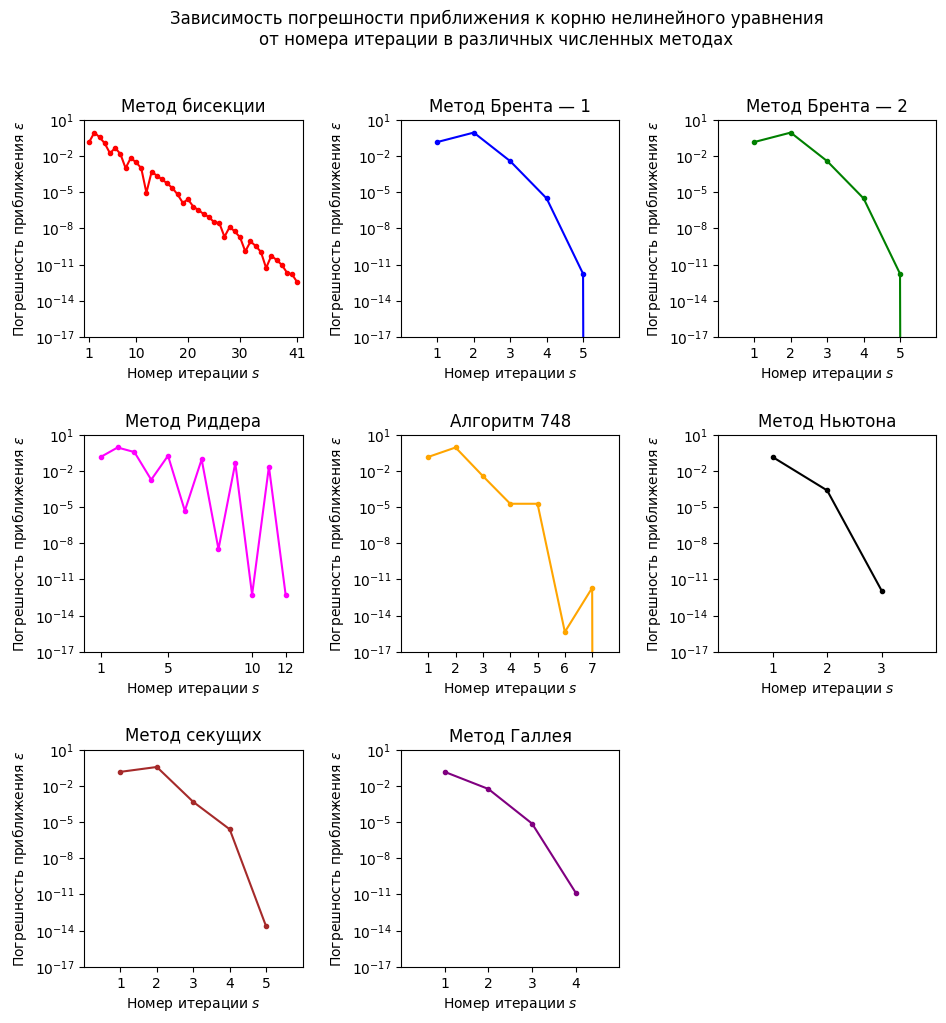

In [168]:
plot_methods(*eps_methods())

Сравнение графиков показывает, что **в смысле числа итераций** наиболее эффективным оказывается метод Ньютона (при прочих равных условиях ему понадобилось всего три итерации). Однако если сравнивать методы **в целом**, учитывая не только скорость сходимости, но и надёжность, а также требования к функции $f(x)$, то наилучшим надо считать метод Брента ("настоящий"). Как правило, именно его следует использовать на практике.

В заключение отметим, что можно выполнять поиск решения нелинейного уравнения, используя следующий приём. Сначала для уточнения корня можно применить метод, не слишком чувствительный к начальному приближению. А затем, "подойдя поближе" к корню, можно переключиться на расчёт новых приближений по методу Ньютона. В таком случае удастся совместить сильные стороны различных методов и предложить эффективный способ решения уравнения.

# Практические задачи

## Задача А

1. Написать программу, реализующую метод Ньютона численного решения нелинейного уравнения вида $f(x)=0$.

2. С помощью написанной программы найти **все** корни уравнения c левой частью $f(x)=\sin x +x^2-1$. Предварительно локализовать корни (например, с помощью графика функции). Указать для каждого корня $x=\xi_i$ множество допустимых начальных приближений, т.е. такое множество $M_i\subset\mathbb{R}$, что при $x^{(0)}\in M_i$ метод Ньютона сходится к корню $x=\xi_i$.

При решении задачи можно воспользоваться указаниями, содержащимися в видеоматериале по [ссылке](https://vkvideo.ru/video-212608323_456239042) (см. также список рекомендованных источников). Советуем обратить внимание на задачу №11.13 из главы IV учебного пособия "Практические занятия по вычислительной математике в МФТИ. Часть I" (авторы — Е.Н. Аристова, Н.А. Завьялова, А.И. Лобанов; издание 2021 г., стр. 102).

# Литература и другие источники

**Видеозаписи:**

1. Вычислительная математика — лекция 6. Лектор — Е.Н. Аристова. [Ссылка](https://m.youtube.com/watch?v=BUTUuvs724M&t=28m49s) (YouTube).

2. Вычислительная математика — лекция 7. Лектор — Е.Н. Аристова. [Ссылка](https://m.youtube.com/watch?v=0UtUfkqH7v8&pp=0gcJCRsBo7VqN5tD&t=62s) (YouTube).

3. Вычислительная математика — лекция 12. Лектор — А.В. Чикиткин. [Ссылка](https://m.youtube.com/watch?v=t0biwmkGZzg) (YouTube).

4. Методы численного решения нелинейных уравнений — видеоразбор темы. Преподаватель — Т.Ю. Салихова. [Ссылка](https://vkvideo.ru/video-212608323_456239032) (VK Видео).

5. Метод Ньютона — указания к практической работе. Преподаватель — М.Н. Петров. [Ссылка](https://vkvideo.ru/video-212608323_456239042) (VK Видео).

**Рекомендуемая литература (с комментариями):**

1.  *В.И. Косарев. 12 лекций по вычислительной математике* — лекция 1, стр. 11—22.

2.  *В.М. Вержбицкий. Численные методы. Линейная алгебра и нелинейные уравнения* — глава 5, стр. 141—211.

3.  *А.А. Амосов, Ю.А. Дубинский, Н.В. Копченова. Вычислительные методы для инженеров* — глава 4, стр. 80—121.

4.  *Б.П. Демидович, И.А. Марон. Основы вычислительной математики* — главы IV и V, стр. 112—198. Книга содержит наилучшее изложение метода хорд. Много внимание уделено вопросам локализации корней.

5.  *И.О. Арушанян. Численные алгоритмы решения нелинейных уравнений.* [Ссылка.](https://num-anal.srcc.msu.ru/prac_pos/poslist/posobie%203%20iarush%202018.pdf) Очень хорошее пособие с грамотным изложением многих вопросов, которые в других источниках излагаются с неточностями.

6.  *Дж. Дэннис, Р. Шнабель. Численные методы безусловной оптимизации и решения нелинейных уравнений.*

7.  *Н.Н. Калиткин, Е.А. Альшина. Численный анализ.* Первый том учебника “Численные методы” (в двух книгах). К теме семинара относится пункт 2.2 главы 2 (стр. 41—55).

8.  *М.П. Галанин, Е.Б. Савенков. Методы численного анализа математических моделей* — глава 2 части I (стр. 86—101).

9.  *А.А. Самарский, А.В. Гулин. Численные методы* — первые три параграфа главы 5 (стр. 190—207).

10.  *В.И. Крылов, В.В. Бобков, П.И. Монастырный. Начала теории вычислительных методов. Линейная алгебра и нелинейные уравнения* — параграфы 17—20 (материал о системах нелинейных уравнений пока можно пропускать), стр. 218—275.

11.  *И.С. Березин, Н.П. Жидков. Методы вычислений. Том второй* — глава 7, за исключением параграфа 5, стр. 76—176. Много информации, не встречающейся в других источниках.

12.  *В.А. Ильина, П.К. Силаев. Численные методы для физиков-теоретиков.* Единственная русскоязычная книга (не считая задачника по курсу), содержащая сведения о так называемом "адаптированном методе Брента" (стр. 48—50). Встречается много опечаток. Изложение фрагментарное. Этим источником следует пользоваться с большой осмотрительностью!

Дополнительная литература:

13.  *И.О. Арушанян. Избранные задачи для семинарских занятий по численным методам решения нелинейных уравнений и систем.* [Ссылка.](https://num-anal.srcc.msu.ru/prac_pos/poslist/posobie19.pdf)

14. *Р.С. Пастушков. Задачи и упражнения по вычислительной математике. V семестр. Решения, указания, ответы.* Напомним, что это пособие есть в библиотеке МФТИ. В электронном виде его легче всего скачать с сайта О.А. Пырковой (см. ниже).

**Сайты и другие электронные ресурсы:**

1. Персональный сайт преподавателя МФТИ О.А. Пырковой. Содержит много полезных материалов по различным математическим курсам МФТИ. Страница с материалами осеннего семестра по вычислительной математике: [ссылка](https://www.pyrkovaoa-fizteh.ru/консультация-вычм-5/).

2. Scientific Python Lectures. Очень полезный ресурс, представляющий собой учебник по научному программированию на языке Python. Представлено много различных библиотек. Есть pdf-версия. Все материалы на английском языке. [Ссылка.](https://lectures.scientific-python.org/)

3. Python Programming And Numerical Methods: A Guide For Engineers And Scientists. Прекрасный сайт, представляющий собой электронную версию одноимённой книги по научному программированию на Python. Исключительно подробное изложение с многочисленными примерами. [Ссылка.](https://pythonnumericalmethods.studentorg.berkeley.edu/notebooks/Index.html)

# Контрольные вопросы

1. Назовите два основных этапа численного решения нелинейных уравнений. Какова цель каждого из этапов?
2. Что такое отрезок локализации корня нелинейного уравнения?
3. Известно, что на границах отрезка $[a,b]$ непрерывная функция $f(x)$ принимает значения разных знаков: $f(a)f(b)<0$. Что можно сказать о количестве корней уравнения $f(x)=0$ на отрезке $[a,b]$?
4. На какие два класса делятся методы численного решения нелинейных уравнений? Чем они отличаются? Приведите примеры методов каждого класса.
5. Опишите алгоритм метода половинного деления. Какие требования предъявляет метод к функции $f(x)$ из левой части уравнения $f(x)=0$? Всегда ли он сходится?
6. Перечислите достоинства и недостатки метода половинного деления.
7. Опишите алгоритм метода хорд. Всегда ли он сходится? В каких случаях сходимость можно гарантировать?
8. Перечислите достоинства и недостатки метода хорд.
9. Пусть требуется организовать некоторый итерационный процесс уточнения корня нелинейного уравнения $f(x)=0$ с **односторонней** сходимостью приближений к корню. Можно ли использовать в качестве критерия остановки итераций малость итерационной поправки $|c_s-c_{s-1}|$? близость значения функции $f(c_s)$ к нулю? Почему?
10. Предложите корректные критерии остановки итераций для методов с односторонней сходимостью приближений к корню.
11. Опишите алгоритмы метода секущих и "адаптированного метода Брента". Есть ли смысл пользоваться ими на практике? Почему?
12. Раскройте суть метода простых итераций (МПИ). Какие трудности возникают при его организации?
13. Сформулируйте достаточное условие сходимости МПИ.
14. Напишите расчётную формулу метода Ньютона и сформулируйте достаточное условие его сходимости.
15. Зависит ли скорость сходимости метода Ньютона от кратности корня? Если зависит, то как?
16. Перечислите достоинства и недостатки метода Ньютона.

*Версия от 28.10.2025*